# Cortical Thickness Growth Gradients

---

This notebook will use the trained SNM (from 05) to characterize growth charts of cortical thickness as gradients (neuromaps) differentiating cortical areas based on their normative growth trajectories.


### Package imports and basic functions

---

In [1]:
import os
import gc
import sys
import glob
import shutil
import json
import random
import datetime
import importlib
import itertools
import numpy as np
from scipy import spatial
import scipy.sparse as sparse
import scipy.stats as stats
import pandas as pd
import nibabel as nib
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import boto3
from tqdm.auto import tqdm
from urllib.parse import urlparse
import requests
import zipfile
from pathlib import Path
import polars as pl
import colorcet as cc
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.image as mpimg
import joblib
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.gridspec as gridspec
from matplotlib.gridspec import GridSpec
import sklearn
from scipy.cluster import hierarchy
import matplotlib.colors as mcolors


In [2]:
%load_ext autoreload
%autoreload 2

# Path to add to src folder (to use local version of spectranorm)
sys.path.append(os.path.abspath("/mountpoint/code/projects/spectranorm/package/spectranorm/src/"))

from spectranorm import snm


In [3]:
class MyNumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        elif isinstance(obj, np.floating):
            return float(obj)
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        else:
            return super(MyEncoder, self).default(obj)


def ensure_dir(file_name):
    os.makedirs(os.path.dirname(file_name), exist_ok=True)
    return file_name


def list_dirs(path=os.getcwd()):
    files = glob.glob(os.path.join(path, '*'))
    files = [x for x in files if os.path.isdir(x)]
    return files


def file_exists(file_name, path_name=os.getcwd()):
    return os.path.isfile(os.path.join(path_name, file_name))


def write_json(json_obj, file_path):
    with open(file_path, 'w') as outfile:
        json.dump(json_obj, outfile, sort_keys=True, indent=4,
                  cls=MyNumpyEncoder)
    return json_obj


def load_json(file_path):
    with open(file_path, 'r') as infile:
        return json.load(infile)


def write_np(np_obj, file_path):
    with open(file_path, 'wb') as outfile:
        np.save(outfile, np_obj)


In [4]:
from PIL import Image as PILImage
from IPython.display import display
import warnings

warnings.simplefilter('ignore', PILImage.DecompressionBombWarning)

def show_image(image_path, width=1000, resample=PILImage.LANCZOS):
    """
    Display an image in Jupyter at a fixed width while preserving aspect ratio.
    The image is resampled (not embedded full-size) to reduce notebook memory.
    """
    img = PILImage.open(image_path).copy()
    w, h = img.size
    new_h = int(h * width / w)
    img = img.resize((width, new_h), resample)
    display(img)

def gaussian_transformation(data, mu, sigma):
    return stats.norm(loc=mu, scale=sigma).pdf(data)

def signal_to_centile(signal):
    return ((stats.rankdata(signal, method='average') - 1) / (len(signal) - 1)) * 100

# a function that turns a set of positive weighted vectors to a weighted average operator (sum of weights will be scaled to 1)
def average_operator(signals):
    return sklearn.preprocessing.normalize(signals, norm='l1', axis=1)

In [5]:
# use tex for plotting
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Computer Modern']


### Brain visualization functions

---

Brain visualization scripts (utilizing [Cerebro Brain Viewer](https://cerebro-viewer.readthedocs.io/en/latest/))

In [6]:
# Cerebro brain viewer used for visualization
from cerebro import cerebro_brain_utils as cbu
from cerebro import cerebro_brain_viewer as cbv


In [7]:
# basic parameters
surface = 'pial'
expand = 0

# load an example dscalar
dscalar_file = cbu.cifti_template_file
dscalar = nib.load(dscalar_file)

brain_models = [x for x in dscalar.header.get_index_map(1).brain_models]

# load surfaces for visualization
left_surface_file, right_surface_file = cbu.get_left_and_right_GIFTI_template_surface(surface)
left_surface = nib.load(left_surface_file)
right_surface = nib.load(right_surface_file)

# extract surface information
lx, ly, lz = left_surface.darrays[0].data.T
lt = left_surface.darrays[1].data
rx, ry, rz = right_surface.darrays[0].data.T
rt = right_surface.darrays[1].data

# combine into a complete brain
lrx = np.concatenate([lx - expand, rx + expand])
lry = np.concatenate([ly, ry])
lrz = np.concatenate([lz, rz])
lrt = np.concatenate([lt, (rt + lx.shape[0])])

lxyz = left_surface.darrays[0].data
rxyz = right_surface.darrays[0].data
lrxyz = np.array([lrx, lry, lrz]).T

# create a mapping between surface and cifti vertices
left_cortical_surface_model, right_cortical_surface_model = brain_models[0], brain_models[1]
cifti_to_surface = {}
surface_to_cifti = {}
for (i, x) in enumerate(left_cortical_surface_model.vertex_indices):
    cifti_to_surface[i] = x
    surface_to_cifti[x] = i
for (i, x) in enumerate(right_cortical_surface_model.vertex_indices):
    cifti_to_surface[i + right_cortical_surface_model.index_offset] = x + rx.shape[0]
    surface_to_cifti[x + rx.shape[0]] = i + right_cortical_surface_model.index_offset

# construct data over surface
surface_mask = list(surface_to_cifti.keys())


In [8]:
# Brain visualizations with Cerebro

# ignore warning when loading cifti
nib.imageglobals.logger.setLevel(40)

# suppress Mesa/GL warnings
os.environ["LIBGL_DEBUG"] = "quiet"

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.gridspec import GridSpec

def plot_single_view_with_cerebro(
        dscalar_data, ax, colormap=plt.cm.coolwarm, clims=None, vlims=None, exclusion_color=(1.,1.,1.,0),
        view="L", show_colorbar=False, colorbar_format=None, cifti_left_right_seperation=0,
        surface = 'midthickness', spheres=None):
    try:
        
        my_brain_viewer = cbv.Cerebro_brain_viewer(offscreen=True, background_color=(1.,1.,1.,0), null_color=(1., 1., 1., 0.0), no_color=(0.7, 0.7, 0.7, 1.))

        surface_model = my_brain_viewer.load_template_GIFTI_cortical_surface_models(surface)

        cifti_space = my_brain_viewer.visualize_cifti_space(
            volumetric_structures='none', cifti_left_right_seperation=cifti_left_right_seperation,
        )

        dscalar_layer = my_brain_viewer.add_cifti_dscalar_layer(
            dscalar_data=dscalar_data,
            colormap=colormap,
            clims=clims,
            vlims=vlims,
            exclusion_color=exclusion_color,
            opacity=0.95)
        
        if spheres is not None:
            my_brain_viewer.visualize_spheres(
                coordinates=spheres[0] + (spheres[2] @ np.array([[cifti_left_right_seperation/2, 0, 0]])),
                radii=1*np.ones(spheres[0].shape),
                color=spheres[1],
            )

        ax.axis('off')
        camconf = my_brain_viewer._view_to_camera_config(view)
        # camconf = my_brain_viewer.zoom_camera_to_content(camconf)
        my_brain_viewer.viewer.change_view(**camconf)
        my_brain_viewer.offscreen_draw_to_matplotlib_axes(ax)

    finally:
        my_brain_viewer.viewer.window.destroy()

def plot_left_right_surface_with_cerebro(dscalar_data, fig, ax, colormap=plt.cm.coolwarm, clims=None, show_colorbar=False, spheres=None, colorbar_format=None, **kwargs):
    # Hide the parent axis
    ax.set_visible(False)

    # Create a 2x2 GridSpec within the axis using inset_axes
    gs = ax.inset_axes([0, 0, 1, 1], transform=ax.transAxes)
    sub_gs = GridSpec(2, 2, gs, hspace=0., wspace=0.)

    # Create a 4x4 grid
    ax_tl = fig.add_subplot(sub_gs[0, 0])
    ax_tr = fig.add_subplot(sub_gs[0, 1])
    ax_bl = fig.add_subplot(sub_gs[1, 0])
    ax_br = fig.add_subplot(sub_gs[1, 1])
    
    # separate data to left and right
    dscalar_data_left = dscalar_data.copy()
    dscalar_data_left[left_cortical_surface_model.index_count:] = np.nan
    dscalar_data_right = dscalar_data.copy()
    dscalar_data_right[:left_cortical_surface_model.index_count] = np.nan
    
    # separate spheres to left and right
    if spheres is None:
        left_spheres = None
        right_spheres = None
    else:
        left_spheres_mask = (spheres[2][:,0] == -1)
        left_spheres = [spheres[0][left_spheres_mask], spheres[1], spheres[2][left_spheres_mask]]
        right_spheres_mask = (spheres[2][:,0] == 1)
        right_spheres = [spheres[0][right_spheres_mask], spheres[1], spheres[2][right_spheres_mask]]
    
    # Lateral left view
    plot_single_view_with_cerebro(dscalar_data_left, ax_tl, colormap=colormap, clims=clims,
                                  view=((-420, 0, 0), None, None, None), spheres=left_spheres, **kwargs)
    # Medial left view
    plot_single_view_with_cerebro(dscalar_data_left, ax_bl, colormap=colormap, clims=clims,
                                  view=((420, 0, 0), None, None, None), spheres=left_spheres, cifti_left_right_seperation=-80, **kwargs)
    
    # Lateral right view
    plot_single_view_with_cerebro(dscalar_data_right, ax_tr, colormap=colormap, clims=clims,
                                  view=((420, 0, 0), None, None, None), spheres=right_spheres, **kwargs)
    # Medial right view
    plot_single_view_with_cerebro(dscalar_data_right, ax_br, colormap=colormap, clims=clims,
                                  view=((-420, 0, 0), None, None, None), spheres=right_spheres, cifti_left_right_seperation=-80, **kwargs)

    if show_colorbar:
        cax = inset_axes(
            ax,
            width="30%",
            height="4%",
            loc="center",
            bbox_to_anchor=(-0., 0.0, 1., 1.),
            bbox_transform=ax.transAxes,
            borderpad=0,
        )
        cb = fig.colorbar(
            mpl.cm.ScalarMappable(
                norm=mpl.colors.Normalize(vmin=clims[0], vmax=clims[1]),
                cmap=colormap
            ),
            cax=cax,
            aspect=10,
            orientation='horizontal',
            format=colorbar_format,
        )
        cb.outline.set_visible(False)
        cb.ax.tick_params(labelsize=12)
        cb.ax.tick_params(length=0)


In [9]:
# Brain visualizations only single hemi

def plot_left_surface_with_cerebro(dscalar_data, fig, ax, colormap=plt.cm.coolwarm, clims=None, show_colorbar=False, spheres=None, colorbar_format=None, **kwargs):
    # Hide the parent axis
    ax.set_visible(False)

    # Create a 2x2 GridSpec within the axis using inset_axes
    gs = ax.inset_axes([0, 0, 1, 1], transform=ax.transAxes)
    sub_gs = GridSpec(1, 2, gs, hspace=0., wspace=0.)
    ax_l = fig.add_subplot(sub_gs[0, 0])
    ax_r = fig.add_subplot(sub_gs[0, 1])
    
    # separate data to left and right
    dscalar_data_left = dscalar_data.copy()
    dscalar_data_left[left_cortical_surface_model.index_count:] = np.nan
    
    # separate spheres to left and right
    if spheres is None:
        left_spheres = None
        right_spheres = None
    else:
        left_spheres_mask = (spheres[2][:,0] == -1)
        left_spheres = [spheres[0][left_spheres_mask], spheres[1], spheres[2][left_spheres_mask]]
    
    # Lateral left view
    plot_single_view_with_cerebro(dscalar_data_left, ax_l, colormap=colormap, clims=clims,
                                  view=((-420, 0, 0), None, None, None), spheres=left_spheres, **kwargs)
    # Medial left view
    plot_single_view_with_cerebro(dscalar_data_left, ax_r, colormap=colormap, clims=clims,
                                  view=((420, 0, 0), None, None, None), spheres=left_spheres, cifti_left_right_seperation=-80, **kwargs)

    if show_colorbar:
        cax = inset_axes(
            ax,
            width="30%",
            height="4%",
            loc="bottom",
            bbox_to_anchor=(-0., 0.0, 1., 1.),
            bbox_transform=ax.transAxes,
            borderpad=0,
        )
        cb = fig.colorbar(
            mpl.cm.ScalarMappable(
                norm=mpl.colors.Normalize(vmin=clims[0], vmax=clims[1]),
                cmap=colormap
            ),
            cax=cax,
            aspect=10,
            orientation='horizontal',
            format=colorbar_format,
        )
        cb.outline.set_visible(False)
        cb.ax.tick_params(labelsize=12)
        cb.ax.tick_params(length=0)


### Spin-test functions

---

Fast parallelized nonparametric spin-tests

In [10]:
# an efficient, parallelized implementation of spin-test, combined with network-based statistic
# modified from this source: https://github.com/sina-mansour/neural-identity/blob/master/codes/spintest.py

import os
import numpy as np
import scipy.spatial as spatial
import scipy.stats as stats
import nibabel as nib
from statsmodels.stats.multitest import multipletests


def compute_statistic_network(data_list, method='pearson', return_pval=True, rotation_transform=None):
    """
    Compute upper-triangular correlation (and optionally p-value) vectors
    from a list of vectors (maps). Supports 'pearson' or 'spearman' methods.

    Parameters
    ----------
    data_list : list of np.ndarray
        List of vectors (1D arrays) of equal length.
    method : str
        'pearson' or 'spearman'.
    return_pval : bool
        Whether to compute and return p-values.

    Returns
    -------
    r_vec : np.ndarray
        Symmetric matrix of correlation coefficients.
    p_vec : np.ndarray or None
        Symmetric matrix of p-values (if return_pval=True).
    """
    n = len(data_list)
    n_v = len(data_list[0])
    i_idx, j_idx = np.triu_indices(n, k=1)
    n_pairs = len(i_idx)

    r_vec = np.full(n_pairs, np.nan)
    p_vec = np.full(n_pairs, np.nan) if return_pval else None

    X = np.array(data_list, dtype=float)

    for k, (i, j) in enumerate(zip(i_idx, j_idx)):
        x, y = X[i], X[j]

        if rotation_transform is not None:
            y = y[rotation_transform]
        
        mask = ~np.isnan(x) & ~np.isnan(y)
        x, y = x[mask], y[mask]

        if method == 'spearman':
            # Rank-transform the data for Spearman
            x, y = stats.rankdata(x), stats.rankdata(y)
            
        if mask.sum() >= 3:  # too few points overlap
            # Use np.corrcoef for speed if p not needed
            if not return_pval:
                r_vec[k] = np.corrcoef(x, y)[0, 1]
            else:
                # if method == 'spearman':
                #     r, p = stats.spearmanr(x, y)
                # else:
                #     r, p = stats.pearsonr(x, y)
                # r_vec[k], p_vec[k] = r, p
                r_vec[k], p_vec[k] = stats.pearsonr(x, y)

    return (r_vec, p_vec)

def get_rotated_statistics_network(random_seed, vertices_l, vertices_r,
                                   data_list, ckdtree_l, ckdtree_r,
                                   method='pearson'):
    """Get the rotated statistics for a given random seed"""
    # set random seed
    rng = np.random.default_rng(seed=random_seed)

    # generate a random spins and rotation transform
    A = rng.normal(0, 1, (3, 3))
    TL, temp = np.linalg.qr(A)
    TL = TL.dot(np.diag(np.sign(np.diag(temp))))
    if (np.linalg.det(TL) < 0):
        TL[:, 0] = -TL[:, 0]
    I1 = np.diag([-1, 1, 1])
    TR = I1.dot(TL.dot(I1))

    # get rotated vertices
    rotated_vertices_l = vertices_l.dot(TL)
    rotated_vertices_r = vertices_r.dot(TR)

    # find nearest neighbors
    Il = ckdtree_l.query(rotated_vertices_l, workers=-1)[1]
    Ir = ckdtree_r.query(rotated_vertices_r, workers=-1)[1]

    # Combine to a single lookup index
    n_l = len(vertices_l)
    I = np.concatenate([Il, Ir + n_l])
    
    stats_1 =  compute_statistic_network(data_list, method=method, return_pval=False, rotation_transform=I)

    # Also apply the inverse rotation
    TL = TL.T
    TR = I1.dot(TL.dot(I1))

    # get rotated vertices
    rotated_vertices_l = vertices_l.dot(TL)
    rotated_vertices_r = vertices_r.dot(TR)

    # find nearest neighbors
    Il = ckdtree_l.query(rotated_vertices_l, workers=-1)[1]
    Ir = ckdtree_r.query(rotated_vertices_r, workers=-1)[1]

    # Combine to a single lookup index
    I = np.concatenate([Il, Ir + n_l])
    
    stats_2 =  compute_statistic_network(data_list, method=method, return_pval=False, rotation_transform=I)

    return [stats_1, stats_2]

def get_nonparametric_pvals(real_rhos, null_rhos_arr, two_tailed=False):
    if two_tailed:
        np_pvals = np.mean(np.abs(null_rhos_arr) >= np.abs(real_rhos), axis=0)
    else:
        np_pvals = np.array([
            np.mean(null_rhos_arr[:, i] >= real_rhos[i]) if real_rhos[i] >= 0
            else np.mean(null_rhos_arr[:, i] <= real_rhos[i])
            for i in range(len(real_rhos))
        ])
    return np_pvals

def detect_clusters(p_vals, i_idx, j_idx, cluster_forming_threshold=0.01):
    """
    Given a boolean mask of suprathreshold edges, return
    - cluster_labels for each edge
    - cluster_sizes for each edge
    """
    n_edges = len(p_vals)
    n_nodes = int((1 + np.sqrt(1 + 8 * n_edges)) / 2)
    cluster_labels = np.zeros(n_edges, dtype=int)
    cluster_sizes = np.zeros(n_edges, dtype=int)
    suprathreshold_mask = p_vals < cluster_forming_threshold
    row = i_idx[suprathreshold_mask]
    col = j_idx[suprathreshold_mask]

    if len(row) == 0:
        return cluster_labels, cluster_sizes

    # Build sparse adjacency matrix of suprathreshold edges
    data = np.ones(len(row), dtype=int)
    adj = sparse.coo_matrix((data, (row, col)), shape=(n_nodes, n_nodes))
    adj = adj + adj.T

    # Compute connected components
    n_components, labels_nodes = sparse.csgraph.connected_components(adj, directed=False, connection='weak')

    # Map back to edges
    component_ids = np.arange(1, n_components + 1)
    for cid in component_ids:
        nodes_in_comp = np.where(labels_nodes == cid - 1)[0]
        # Only need to check one end of the edge (i_idx) for membership
        mask_edges = suprathreshold_mask.copy()
        mask_edges[suprathreshold_mask] = np.isin(i_idx[suprathreshold_mask], nodes_in_comp)
        cluster_labels[mask_edges] = cid
        cluster_sizes[mask_edges] = np.sum(mask_edges)

    return cluster_labels, cluster_sizes


def perform_nbs(real_rhos, null_rhos, cluster_forming_threshold=0.05, two_tailed=False):
    """
    Perform Network-Based Statistic (NBS) correction for edgewise correlation tests
    using scipy for connected component detection (no networkx).

    Parameters
    ----------
    real_rhos : array, shape (n_edges,)
        Real correlation values for upper-triangular edges.
    null_rhos : array, shape (n_permutations, n_edges)
        Null correlations (permuted data), same ordering as real_rhos.
    cluster_forming_threshold : float
        P-value threshold for cluster formation (default=0.01).
    two_tailed : bool
        Whether to compute two-tailed p-values. Default False

    Returns
    -------
    nbs_pvals : array, shape (n_edges,)
        Cluster-level corrected p-values for each edge (np.nan for subthreshold edges).
    nbs_cluster_labels : array, shape (n_edges,)
        Cluster label for each suprathreshold edge (0 for subthreshold).
    nbs_cluster_sizes : array, shape (n_edges,)
        Size of the cluster (number of edges) for each suprathreshold edge.
    """
    n_edges = len(real_rhos)
    n_perms = null_rhos.shape[0]

    # Upper-triangle node indices
    n_nodes = int((1 + np.sqrt(1 + 8 * n_edges)) / 2)
    i_idx, j_idx = np.triu_indices(n_nodes, k=1)

    # Initialize retrning values
    nbs_pvals = np.full(n_edges, np.nan)

    # Detect cluster in real data
    p_vals = get_nonparametric_pvals(real_rhos, null_rhos, two_tailed=two_tailed)
    cluster_labels, cluster_sizes = detect_clusters(
        p_vals, i_idx, j_idx, cluster_forming_threshold=cluster_forming_threshold)

    # No clusters
    if cluster_sizes.max() == 0:
        return (nbs_pvals, cluster_labels, cluster_sizes)

    # Compute null max cluster sizes
    null_max_cluster_sizes = np.zeros(n_perms)
    for p in range(n_perms):
        p_vals = get_nonparametric_pvals(null_rhos[p], null_rhos, two_tailed=two_tailed)
        _, null_sizes = detect_clusters(
            p_vals, i_idx, j_idx, cluster_forming_threshold=cluster_forming_threshold)
        null_max_cluster_sizes[p] = null_sizes.max()

    # Compute cluster-level p-values (NBS corrected p-vals)
    nbs_pvals = np.array([
        np.mean(null_max_cluster_sizes >= csize)
        for csize in cluster_sizes
    ])

    return nbs_pvals, cluster_labels, cluster_sizes


def non_parametric_spin_test_multipletests_network(
        data_list,
        vertices_l,
        vertices_r,
        n_jobs=1,
        permutations=1000,
        random_seed=0,
        method='pearson',
        two_tailed=False,
        cluster_forming_p_value_threshold=0.01,
        fdr_method='fdr_bh',
        nonparametric_correction_methods=('FWER', 'FDR', 'NBS')):
    """
    Calculate the p-value of correlation between all pairs of neuromaps (data_list)
    based on a null distribution made via spins of the maps.

    Multiple testing (FDR/FWER) between all pairs will be controlled by NBS
    (Network-Based Statistic), controlling for the error rate at the level
    of networks.

    Args:
        data_list (list of lists/numpy arrays):
            surface maps data to compare against (length N).
        vertices_l (array):
            x,y,z location of each suraface vertex from left surface
            sphere mesh (shape (N,3)).
        vertices_r (array):
            x,y,z location of each suraface vertex from right surface
            sphere mesh (shape (N,3)).
        permutations (int):
            The number of permutations, default=1000.
        random_seed (int):
            Seed used for replicability in the random number generation.
            defualt=None,
        method (string):
            Choice of correspondence methods: from "pearson" and "spearman".
        two_tailed (bool):
            a flag to indicate whether the non-parametric test should be
            one- or two-tailed. default=False
        fdr_method (string):
            Choice of the correction approach for FDR correction (default='fdr_bh')
        nonparametric_correction_methods (list/tuple):
            The statistical approaches to correct for multiple comparisons.
            Possible options:
                'FWER':
                    non-parametric FWER correction (max-T approach)
                'FDR':
                    non-parametric FDR correction (FDR on non-parametric
                    permutation p-values)
                'NBS':
                    non-parametric cluster-level correction of FWER (in a weak
                    sense) using the network based statistic, p-values for each
                    pair comes from the p-value computed for the cluster.
            (Default includes all approaches, less efficient)

    Returns:
        dict:
            {
                'corellation r': The Pearson/Spearman corellation of the surface maps,
                'parametric p-val': uncorrected parametric p-value of the correlation in a t-test,
                'non-parametric p-val': uncorrected non-parametric p-value from the spin test (main result),
                'fwer corrected non-parametric p-val': FWER corrected non-parametric p-values (see Winkler et al. 2014),
                'fdr corrected non-parametric p-val': FDR corrected non-parametric p-values (see Winkler et al. 2014),
            }
    """
    # build kd-tree from surfaces (in the unrotated space, used as pivot)
    ckdtree_l = spatial.cKDTree(vertices_l)
    ckdtree_r = spatial.cKDTree(vertices_r)

    # compute the parametric statistic
    real_rhos, parametric_ps = compute_statistic_network(data_list, method=method)
    return_dict = {
        'corellation r': real_rhos,
        'parametric p-val': parametric_ps,
    }

    null_rhos = snm.utils.parallel.ParallelTqdm(
        total_tasks=permutations,
        n_jobs=n_jobs,
        desc="Random permutations")(
        joblib.delayed(get_rotated_statistics_network)(
            random_seed=random_seed + i,
            vertices_l=vertices_l,
            vertices_r=vertices_r,
            data_list=data_list,
            ckdtree_l=ckdtree_l,
            ckdtree_r=ckdtree_r,
            method=method
        )
        for i in range(permutations)
    )
    # flatten the two rotation statistics
    null_rhos = [item for sublist in null_rhos for item in sublist]
    # only keep correlation values
    null_rhos = [x[0] for x in null_rhos]
    null_rhos.append(real_rhos) ## to cap the best achievable p-value at 1/permutations
    null_rhos_arr = np.array(null_rhos)  # shape (perms, n_map_pairs)

    # compute non-parametric p-value
    np_pvals = get_nonparametric_pvals(real_rhos, null_rhos_arr, two_tailed=two_tailed)
    return_dict['non-parametric p-val'] = np_pvals
    
    if len(nonparametric_correction_methods) > 0:
        n_edges = real_rhos.shape[0]
        n_nodes = int((1 + np.sqrt(1 + 8 * n_edges)) / 2)
        i_idx, j_idx = np.triu_indices(n_nodes, k=1)
        node_masks = [(i_idx == i) | (j_idx == i) for i in range(n_nodes)]
        
        if 'FWER' in nonparametric_correction_methods:
            # compute fwer corrected non-parametric p-values
            if two_tailed:
                fwer_np_pvals = np.array([
                    np.mean(np.max(np.abs(null_rhos_arr), axis=1) >= np.abs(r))
                    for r in real_rhos
                ])
            else:
                fwer_np_pvals = np.array([
                    np.mean(np.max(null_rhos_arr, axis=1) >= r) if r >= 0
                    else np.mean(np.min(null_rhos_arr, axis=1) <= r)
                    for r in real_rhos
                ])
            return_dict['FWER corrected non-parametric p-val'] = fwer_np_pvals
    
        # compute fwer corrected non-parametric p-value
        if 'FDR' in nonparametric_correction_methods:
            _, fdr_np_pvals, _, _ = multipletests(np_pvals, method=fdr_method)
            return_dict['FDR corrected non-parametric p-val'] = fdr_np_pvals
    
        # compute NBS corrected p-values
        if 'NBS' in nonparametric_correction_methods:
            NBS_np_pvals, NBS_cluster_labels, NBS_cluster_sizes = perform_nbs(
                real_rhos, null_rhos_arr,
                cluster_forming_threshold=cluster_forming_p_value_threshold,
                two_tailed=two_tailed)
            return_dict['NBS corrected p-val'] = NBS_np_pvals
            return_dict['NBS cluster label'] = NBS_cluster_labels
            return_dict['NBS cluster size'] = NBS_cluster_sizes

    # return the statistics
    return return_dict

def perform_multiple_spin_tests_network(
        data_list,
        vertices_l=lxyz,
        vertices_r=rxyz,
        surface_mask=surface_mask,
        n_jobs=40,
        permutations=5000,
        random_seed=0,
        method='spearman',
        two_tailed=False,
        cluster_forming_p_value_threshold=0.05,):
    """
    Calculate the p-value of correlation between two surface maps
    """
    surface_data_list = [
        np.zeros(vertices_l.shape[0] + vertices_r.shape[0]) * np.nan
        for i in range(len(data_list))
    ]
    for i, data in enumerate(data_list):
        surface_data_list[i][surface_mask] = data

    return non_parametric_spin_test_multipletests_network(
        surface_data_list,
        vertices_l,
        vertices_r,
        n_jobs=n_jobs,
        permutations=permutations,
        random_seed=random_seed,
        method=method,
        two_tailed=two_tailed,
        cluster_forming_p_value_threshold=cluster_forming_p_value_threshold,)

def triu_vector_to_symmetric_matrix(vec):
    """
    Convert an upper-triangular vector (excluding diagonal) into
    a full symmetric matrix with zeros on the diagonal.

    Parameters
    ----------
    vec : np.ndarray
        Vector containing upper-triangular values (k=1).
        Length must equal n*(n-1)/2.

    Returns
    -------
    mat : np.ndarray
        Symmetric (n x n) matrix with zero diagonal.
    """
    n_edges = len(vec)
    n_nodes = int((1 + np.sqrt(1 + 8 * n_edges)) / 2)
    mat = np.zeros((n_nodes, n_nodes), dtype=float)
    i_idx, j_idx = np.triu_indices(n_nodes, k=1)
    mat[i_idx, j_idx] = vec
    mat[j_idx, i_idx] = vec
    return mat

## Load aggregated data

---

In [11]:
demography_df = pd.read_parquet(f'/mountpoint/data/normative/datasets/all_datasets/demography.parquet').reset_index(drop=True)
train_df = demography_df[(demography_df['split'] == "Train")]
test_df = demography_df[~(demography_df['split'] == "Train")]
demography_df.shape, train_df.shape, test_df.shape


((78405, 14), (62724, 14), (15681, 14))

## Load spectral coefficients

---

Load the thickness spectral coefficients computed in 02_03.

In [12]:
# Load encoded data as memory-mapped array (read-only)
spectral_coefficients = np.load(
    "/mountpoint/data/normative/spectral_coefficients/all_datasets.thickness.fslr.10000.npy",
    mmap_mode='r',
)
train_spectral_coefficients = spectral_coefficients[(demography_df['split'] == "Train"), :]
test_spectral_coefficients = spectral_coefficients[~(demography_df['split'] == "Train"), :]
spectral_coefficients.shape, train_spectral_coefficients.shape, test_spectral_coefficients.shape


((78405, 10000), (62724, 10000), (15681, 10000))

## Load Spectral Normative Model

---

Load the Spectral Normative Model (fitted in 05_01)


In [13]:
%%time
spectral_normative_model = snm.SpectralNormativeModel.load_model(
    "/mountpoint/code/projects/normative_brain_charts/data/pretrained_models/full_spectral_normative_model_10000/"
)
eigenmode_basis = spectral_normative_model.eigenmode_basis
spectral_normative_model


CPU times: user 16 s, sys: 2.97 s, total: 19 s
Wall time: 19 s


SpectralNormativeModel(eigenmode_basis=EigenmodeBasis(n_modes=10000, n_features=59412), base_model=DirectNormativeModel(spec=NormativeModelSpec(variable_of_interest='thickness', covariates=[CovariateSpec(name=age, cov_type=numerical, effect=spline), CovariateSpec(name=sex, cov_type=categorical, hierarchical=False, n_categories=2), CovariateSpec(name=site, cov_type=categorical, hierarchical=True, n_categories=189)], influencing_mean=['age', 'sex', 'site'], influencing_variance=['age', 'sex', 'site'])))

## Generate normative vertex-resolution predictions across lifespan

---



In [14]:
from Connectome_Spatial_Smoothing import CSS as css

smoothing_kernel_8mmFWHM_path = f'/mountpoint/code/projects/normative_brain_charts/data/smoothing_kernels/smoothing_kernel_8mmFWHM.npz'
if Path(smoothing_kernel_8mmFWHM_path).exists():
    smoothing_kernel_8mmFWHM = sparse.load_npz(smoothing_kernel_8mmFWHM_path)
else:
    # Create a smoothing kernel
    smoothing_kernel_8mmFWHM = css.compute_smoothing_kernel(left_surface_file, right_surface_file, fwhm=8, epsilon=0.01,)
    sparse.save_npz(ensure_dir(smoothing_kernel_8mmFWHM_path), smoothing_kernel_8mmFWHM)


In [15]:
%%time
high_res_norm_queries = eigenmode_basis.encode(smoothing_kernel_8mmFWHM.T, n_modes=1000)
high_res_norm_queries.shape


CPU times: user 4.35 s, sys: 1.63 s, total: 5.98 s
Wall time: 5.98 s


(59412, 1000)

In [16]:
%%time

min_age, max_age = 5, 95
samples_per_year = 1
candidate_ages = np.linspace(min_age, max_age, samples_per_year * (max_age - min_age) + 1)
dt = 1/24

# predict moments
predicted_moments = spectral_normative_model.predict(
    encoded_query=high_res_norm_queries.T,
    test_covariates=pd.DataFrame({"age": candidate_ages,}),
    predict_without=['site', 'sex'],
    n_modes=1000, # to simplify the inference
).predictions
predicted_moments_plus = spectral_normative_model.predict(
    encoded_query=high_res_norm_queries.T,
    test_covariates=pd.DataFrame({"age": candidate_ages + dt,}),
    predict_without=['site', 'sex'],
    n_modes=1000, # to simplify the inference
).predictions
predicted_moments_minus = spectral_normative_model.predict(
    encoded_query=high_res_norm_queries.T,
    test_covariates=pd.DataFrame({"age": candidate_ages - dt,}),
    predict_without=['site', 'sex'],
    n_modes=1000, # to simplify the inference
).predictions
predicted_rate = (predicted_moments_plus['mu_estimate'] - predicted_moments_minus['mu_estimate']) / (2 * dt)


Computing direct eigenmode estimates:   0%|          | 0/1000 [00:00<?, ?tasks/s]

Computing cross-mode dependence estimates:   0%|          | 0/4889 [00:00<?, ?tasks/s]

Computing direct eigenmode estimates:   0%|          | 0/1000 [00:00<?, ?tasks/s]

/mountpoint/code/projects/spectranorm/environment/spectranorm_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Computing cross-mode dependence estimates:   0%|          | 0/4889 [00:00<?, ?tasks/s]

Computing direct eigenmode estimates:   0%|          | 0/1000 [00:00<?, ?tasks/s]

Computing cross-mode dependence estimates:   0%|          | 0/4889 [00:00<?, ?tasks/s]

CPU times: user 17min 18s, sys: 19min 35s, total: 36min 53s
Wall time: 16min 59s


## Extract lifespan growth gradients

---

Implement a data-driven decomposition of thickness growth charts to extract orthogonal thickness growth components.


In [17]:
cortical_info = (predicted_moments['mu_estimate'] - predicted_moments['mu_estimate'].mean()) / predicted_moments['mu_estimate'].std()
cortical_info.shape

(91, 59412)

In [18]:
%%time
from sklearn.decomposition import PCA

# transpose so shape = (samples, features)
data = cortical_info.T  # shape (59412, 91)

# extract principal components
pca = PCA(n_components=3)
transformed = pca.fit_transform(data)  # shape (59412, 3)

# transpose so shape = (3, 59412)
growth_components = transformed.T  # shape (3, 59412)


CPU times: user 159 ms, sys: 267 ms, total: 425 ms
Wall time: 90.6 ms


In [19]:
(
    pca.explained_variance_ratio_,
    pca.explained_variance_ratio_.sum(),
    pca.explained_variance_ratio_[1:]/(1 - pca.explained_variance_ratio_[0]),
    (pca.explained_variance_ratio_[1:]/(1 - pca.explained_variance_ratio_[0])).sum(),
)

(array([0.97385392, 0.01739875, 0.00652839]),
 0.9977810572908469,
 array([0.66544388, 0.24968897]),
 0.9151328565036436)

## Cortical Thinning Maps

---

Map out the cortical thinning patterns during development and aging periods.


In [20]:
# Developmental Cortical Pruning Map: Mean Percent Change in Thickness from 5 to 20 years of age
developmental_cortical_pruning = (predicted_rate/predicted_moments['mu_estimate'])[candidate_ages <= 20].mean(0)


In [21]:
# Aging Thickness Decline Map: Mean Percent Change in Thickness from 40 to 95 years of age
aging_thickness_decline = (predicted_rate/predicted_moments['mu_estimate'])[candidate_ages >= 40].mean(0)


## Load other brain maps

---

Loading brain maps from previous studies to compare against the gradients of normative thickness growth.

### 3 Components of Gene Expression (Dear et al. 2024)

In [22]:
url = "https://github.com/richardajdear/AHBA_gradients/raw/ab7939cf1811cba6296b882e35e60b09fed7d653/outputs/expression/hcp_3d_ds5.csv"
url = "https://raw.githubusercontent.com/richardajdear/AHBA_gradients/ab7939cf1811cba6296b882e35e60b09fed7d653/outputs/ahba_dme_hcp_top8kgenes_scores.csv"
df = pd.read_csv(url)

# load HCP MMP1.0 parcellaiton
atlas = nib.load("/mountpoint/data/templates/hcp_parcel/Q1-Q6_RelatedValidation210.CorticalAreas_dil_Final_Final_Areas_Group_Colors.32k_fs_LR.dlabel.nii")
atlas_data = atlas.get_fdata()[0]
atlas_label_dict = dict(list(atlas.header.get_index_map(0).named_maps)[0].label_table)
atlas_label_names = {i:atlas_label_dict[i].label for i in atlas_label_dict}
atlas_label_indices = {atlas_label_dict[i].label:i for i in atlas_label_dict}

Gene_PC1 = atlas_data * np.nan
# project the gradients to the cortex
for i, row in df.iterrows():
    # print(row.id, row.C1)
    Gene_PC1[atlas_data == row.id] = row.C1
    Gene_PC1[atlas_data == (row.id + 180)] = row.C1

Gene_PC2 = atlas_data * np.nan
# project the gradients to the cortex
for i, row in df.iterrows():
    # print(row.id, row.C1)
    Gene_PC2[atlas_data == row.id] = row.C2
    Gene_PC2[atlas_data == (row.id + 180)] = row.C2

Gene_PC3 = atlas_data * np.nan
# project the gradients to the cortex
for i, row in df.iterrows():
    # print(row.id, row.C1)
    Gene_PC3[atlas_data == row.id] = row.C3
    Gene_PC3[atlas_data == (row.id + 180)] = row.C3


### Additional maps sourced from Neuromaps

In [23]:
# Nilearn Monkey patch
from pathlib import Path
import neuromaps.datasets.annotations as annots

# Keep reference to the original _fetch_file
orig_fetch_file = annots._fetch_file

def patched_fetch_file(url, data_dir, *args, **kwargs):
    """Ensure data_dir is always a Path."""
    if isinstance(data_dir, str):
        data_dir = Path(data_dir)
    return orig_fetch_file(url, data_dir, *args, **kwargs)

# Apply the patch
annots._fetch_file = patched_fetch_file


/mountpoint/code/projects/spectranorm/environment/spectranorm_env/lib/python3.10/site-packages/neuromaps/datasets/utils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


In [24]:
from neuromaps import datasets, transforms

all_annotations = datasets.fetch_annotation(source="all", data_dir="/mountpoint/code/projects/normative_brain_charts/data/templates/neuromaps")

# remove duplicate volumetric maps of the beliveau2017 source
all_annotations = {
    k: v for k, v in all_annotations.items()
    if not (k[0] == "beliveau2017" and "MNI" in k[2])
}
# remove duplicate volumetric maps of the norgaard2021 source
all_annotations = {
    k: v for k, v in all_annotations.items()
    if not (k[0] == "norgaard2021" and "MNI" in k[2])
}
# remove neuromaps missing both hemispheres data
all_annotations = {
    k: v for k, v in all_annotations.items()
    if not (k[2] == "fsLR" and isinstance(v, str))
}

neuromap_signals = {}
for dataset in tqdm(all_annotations):
    # parse info
    source, desc, space, density = dataset
    # map to fs_lr and store
    if space == 'MNI152':
        loaded = transforms.mni152_to_fslr(all_annotations[dataset])
    elif space == 'civet':
        loaded = transforms.civet_to_fslr(all_annotations[dataset])
    elif space == 'fsaverage':
        loaded = transforms.fsaverage_to_fslr(all_annotations[dataset])
    elif space == 'fsLR':
        loaded = transforms.fslr_to_fslr(all_annotations[dataset])
    else:
        raise ValueError(f"Unsupported space: {space}")
    neuromap_signals[(source, desc)] = np.concatenate([loaded[0].darrays[0].data, loaded[1].darrays[0].data])[surface_mask]
    

/tmp/ipykernel_3692383/239609976.py:3: UserWarning: Data from beliveau2017 and norgaard2021 is best used in the provided fsaverage space (e.g. source='beliveau2017', space='fsaverage', den='164k'). MNI152 maps should only be used for subcortical data.
  all_annotations = datasets.fetch_annotation(source="all", data_dir="/mountpoint/code/projects/normative_brain_charts/data/templates/neuromaps")


  0%|          | 0/71 [00:00<?, ?it/s]

## Statistical tests of correspondence

---


In [25]:
# List all maps
brain_maps = {
    "TGG1": {
        "name": "First Thickness Growth Gradient",
        "map": growth_components[0]
    },
    "TGG2": {
        "name": "Second Thickness Growth Gradient",
        "map": growth_components[1]
    },
    "TGG3": {
        "name": "Third Thickness Growth Gradient",
        "map": growth_components[2]
    },
    "DCP": {
        "name": "Developmental Cortical Pruning",
        "map": developmental_cortical_pruning
    },
    "ATD": {
        "name": "Aging Thickness Decline",
        "map": aging_thickness_decline
    },
    "GEC1": {
        "name": "First Gene Expression Component",
        "map": Gene_PC1
    },
    "GEC2": {
        "name": "Second Gene Expression Component",
        "map": Gene_PC2
    },
    "GEC3": {
        "name": "Third Gene Expression Component",
        "map": Gene_PC3
    },
    "SA": {
        "name": "Sensorimotor-Association Axis",
        "map": neuromap_signals[('sydnor2021', 'SAaxis')]
    },
    "FCG1": {
        "name": "First Functional Connectivity Gradient",
        "map": neuromap_signals[('margulies2016', 'fcgradient01')]
    },
    "FCG2": {
        "name": "Second Functional Connectivity Gradient",
        "map": neuromap_signals[('margulies2016', 'fcgradient02')]
    },
    "CT": {
        "name": "Mean Cortical Thickness",
        "map": neuromap_signals[('hcps1200', 'thickness')]
    },
}

In [26]:
%%time

# Perform spin-test based nonparametric testing across a list of maps
network_stats = perform_multiple_spin_tests_network(
    [brain_maps[brain_map]["map"] for brain_map in brain_maps],
    permutations=10_000, n_jobs=50, method='pearson', two_tailed=True
)


Random permutations:   0%|          | 0/10000 [00:00<?, ?tasks/s]

CPU times: user 2min 31s, sys: 1min 8s, total: 3min 39s
Wall time: 4min 55s


## Cortical Visualizations

---



In [27]:
%%time
# %matplotlib inline
%matplotlib agg

def generate_cortical_projection_plots(fig_name, lims, colormap, brain_signal, store_dir):
    with snm.utils.general.suppress_output():
        fig, ax = plt.subplots(figsize=(12, 9))
        plot_left_right_surface_with_cerebro(brain_signal, fig, ax, clims=lims, show_colorbar=False, colormap=colormap)
        fig.savefig(ensure_dir(f'{store_dir}/subfigs/gradients/{fig_name}_projection.png'), bbox_inches="tight", dpi=600)
        plt.close(fig)
    with snm.utils.general.suppress_output():
        fig, ax = plt.subplots(figsize=(12, 4.5))
        plot_left_surface_with_cerebro(brain_signal, fig, ax, clims=lims, show_colorbar=False, colormap=colormap)
        fig.savefig(ensure_dir(f'{store_dir}/subfigs/gradients/{fig_name}_left_projection.png'), bbox_inches="tight", dpi=600)
        plt.close(fig)

# save path
store_dir='/mountpoint/code/projects/normative_brain_charts/figs/R1'


# A generator for parallel generation of visualizations for Brain_wide signals
def plotting_tasks():
    for brain_map in brain_maps:
        # Projections of the original map
        brain_signal = brain_maps[brain_map]["map"].copy()
        brain_signal[np.isnan(brain_signal)] = np.nanmean(brain_signal)
        mu, sigma = brain_signal.mean(), brain_signal.std()
        lims=[mu - 2 * sigma, mu + 2 * sigma]
        yield joblib.delayed(generate_cortical_projection_plots)(
            fig_name=f'{brain_map}',
            lims=lims, colormap=cc.cm.diverging_tritanopic_cwr_75_98_c20,
            brain_signal=brain_signal, store_dir=store_dir,
        )
        yield joblib.delayed(generate_cortical_projection_plots)(
            fig_name=f'{brain_map}_flipped',
            lims=lims, colormap=cc.cm.diverging_tritanopic_cwr_75_98_c20,
            brain_signal=2*mu - brain_signal, store_dir=store_dir,
        )
        # Projections of the centiles map
        brain_signal = signal_to_centile(brain_signal)
        lims=[0,100]
        yield joblib.delayed(generate_cortical_projection_plots)(
            fig_name=f'{brain_map}_centiles',
            lims=lims, colormap=cc.cm.isoluminant_cgo_80_c38,
            brain_signal=brain_signal, store_dir=store_dir,
        )
        yield joblib.delayed(generate_cortical_projection_plots)(
            fig_name=f'{brain_map}_flipped_centiles',
            lims=lims, colormap=cc.cm.isoluminant_cgo_80_c38,
            brain_signal=100 - brain_signal, store_dir=store_dir,
        )

results = list(snm.utils.parallel.ParallelTqdm(
    total_tasks=(len(brain_maps) * 4),
    n_jobs=30,
    desc="Cortical visualizations: brain maps",
)(plotting_tasks()))


Cortical visualizations: brain maps:   0%|          | 0/48 [00:00<?, ?tasks/s]

CPU times: user 729 ms, sys: 78.9 ms, total: 808 ms
Wall time: 1min 2s


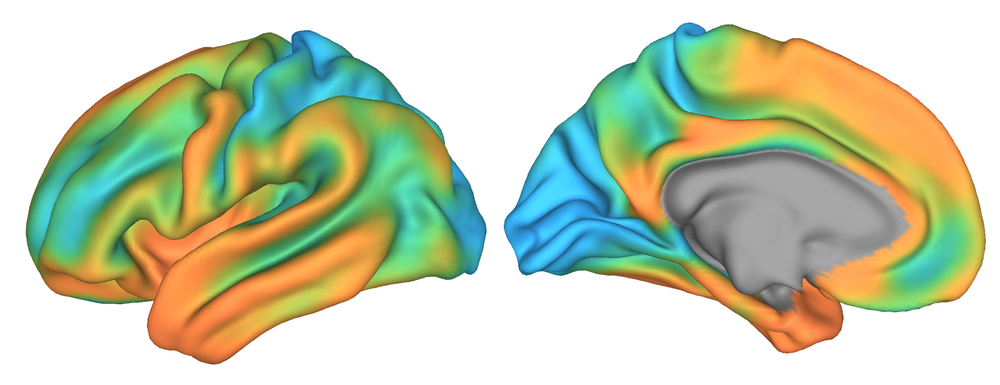

In [28]:
# check a single image to make sure it looks right
image_path = f'{store_dir}/subfigs/gradients/TGG1_centiles_left_projection.png'
show_image(image_path)

## Cortical Visualizations of Gradient Strata

---

Brain maps are divided into 11 similarly sized groups (gradient strata) indicating vertices with similar values along that gradient/map.

In [29]:
from Connectome_Spatial_Smoothing import CSS as css

# Build gradient strata for the 3 lifespan growth gradients, and the cortical pruning maps
centiles = np.linspace(0, 100, 11)
sigma = css._fwhm2sigma((centiles[1] - centiles[0]))
selected_gradients = ["TGG1", "TGG2", "TGG3", "DCP", "ATD", "SA"]
for brain_map in tqdm(selected_gradients):
    # build the queries
    transition_queries = np.array([gaussian_transformation(signal_to_centile(brain_maps[brain_map]["map"]), centile, sigma) for centile in centiles])
    # smooth the queries
    transition_queries = transition_queries @ smoothing_kernel_8mmFWHM
    # store as a property of the map
    brain_maps[brain_map]["Centile Groups"] = transition_queries
    

  0%|          | 0/6 [00:00<?, ?it/s]

In [30]:
%%time
# %matplotlib inline
%matplotlib agg

def generate_cortical_projection_plots(fig_name, lims, colormap, brain_signal, store_dir):
    with snm.utils.general.suppress_output():
        fig, ax = plt.subplots(figsize=(12, 9))
        plot_left_right_surface_with_cerebro(brain_signal, fig, ax, clims=lims, show_colorbar=False, colormap=colormap)
        fig.savefig(ensure_dir(f'{store_dir}/subfigs/gradients/{fig_name}_projection.png'), bbox_inches="tight", dpi=600)
        plt.close(fig)
    with snm.utils.general.suppress_output():
        fig, ax = plt.subplots(figsize=(12, 4.5))
        plot_left_surface_with_cerebro(brain_signal, fig, ax, clims=lims, show_colorbar=False, colormap=colormap)
        fig.savefig(ensure_dir(f'{store_dir}/subfigs/gradients/{fig_name}_left_projection.png'), bbox_inches="tight", dpi=600)
        plt.close(fig)

# save path
store_dir='/mountpoint/code/projects/normative_brain_charts/figs/R1'


# A generator for parallel generation of visualizations for Brain_wide signals
def plotting_tasks():
    for brain_map in selected_gradients:
        for i, centile in enumerate(centiles):
            # Projections of the centiles map
            brain_signal = brain_maps[brain_map]["Centile Groups"][i]
            lims=np.percentile(brain_signal, [0, 99])
            # Colormap from white to the appropriate color
            colormap = LinearSegmentedColormap.from_list(
                'temporary_gradient',((0.0, (1., 1., 1.,)),(1.0, cc.cm.isoluminant_cgo_80_c38(centile/100)[:3]),))
            yield joblib.delayed(generate_cortical_projection_plots)(
                fig_name=f'{brain_map}_centile_group_{i}',
                lims=lims, colormap=colormap,
                brain_signal=brain_signal, store_dir=store_dir,
            )

results = list(snm.utils.parallel.ParallelTqdm(
    total_tasks=(len(selected_gradients) * len(centiles) * 1),
    n_jobs=40,
    desc="Cortical visualizations: centile groups of brain maps",
)(plotting_tasks()))


Cortical visualizations: centile groups of brain maps:   0%|          | 0/66 [00:00<?, ?tasks/s]

CPU times: user 870 ms, sys: 145 ms, total: 1.01 s
Wall time: 1min 1s


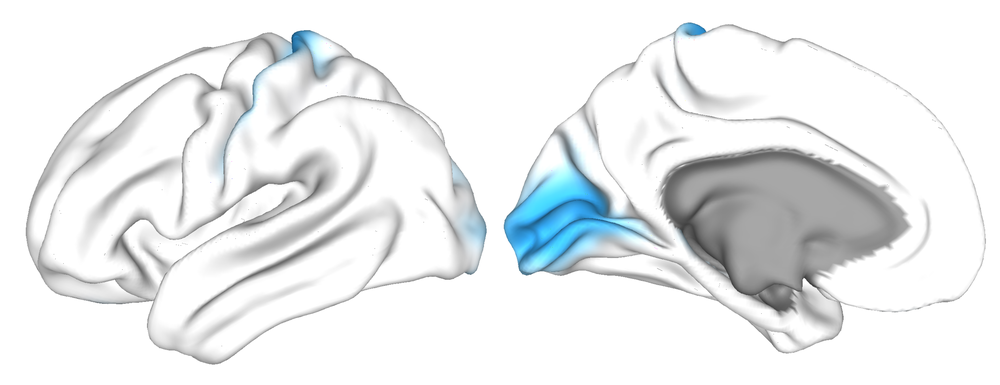

In [31]:
# check a single image to make sure it looks right
image_path = f'{store_dir}/subfigs/gradients/TGG1_centile_group_0_left_projection.png'
show_image(image_path)

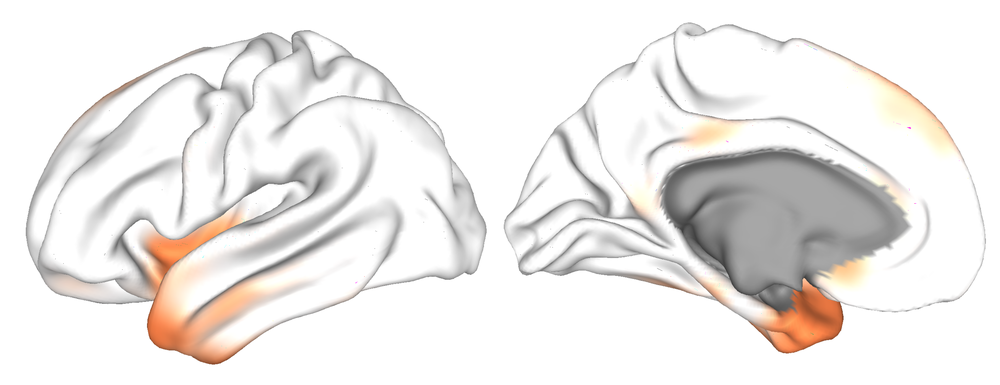

In [32]:
# check a single image to make sure it looks right
image_path = f'{store_dir}/subfigs/gradients/TGG1_centile_group_10_left_projection.png'
show_image(image_path)

### Gradient strata figure

---

Let's visualize the strata and how they were mapped for the manuscript.


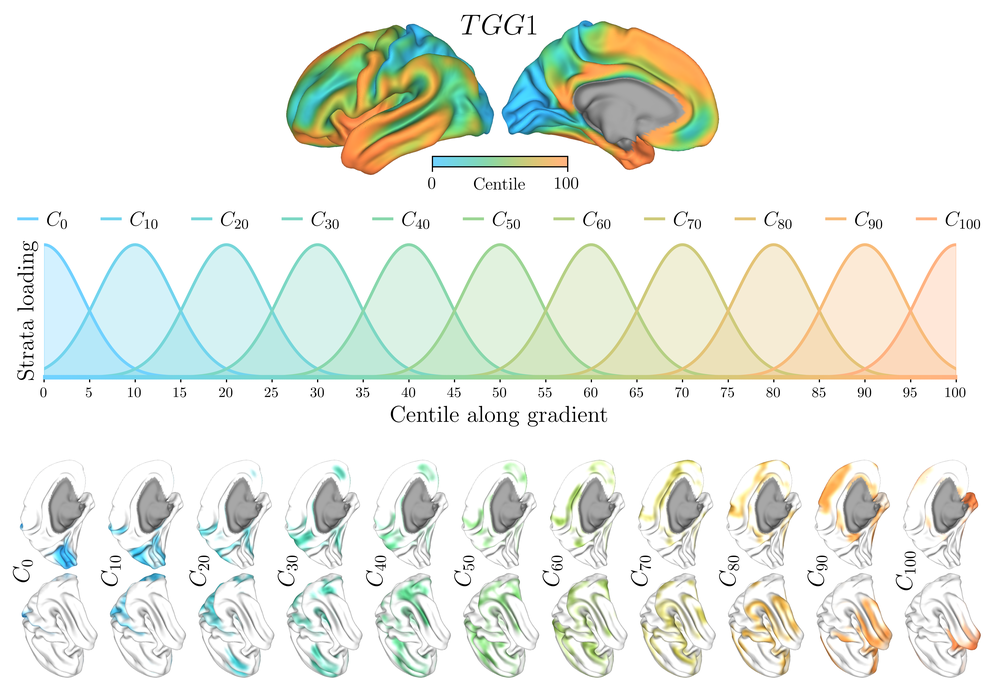

CPU times: user 16.6 s, sys: 3.71 s, total: 20.4 s
Wall time: 20 s


In [33]:
%%time

# save path
store_dir='/mountpoint/code/projects/normative_brain_charts/figs/R1'

fig = plt.figure(figsize=(12, 9))
fig.tight_layout(h_pad=0)
# fig.suptitle(r"\textbf{Brain eigenmodes}", fontsize=36, x=0.5, y=0.96, weight='bold', ha="center")

gs = GridSpec(3, 11, figure=fig, height_ratios=[0.9,0.7,1.4], width_ratios=[1]*11, wspace=0.01, hspace=0.3, top=0.85)  # left=0.2, bottom=0.2, right=0.8, top=0.8, 

# Show TGG2
ax = fig.add_subplot(gs[0, :])
image_path = f'{store_dir}/subfigs/gradients/TGG1_centiles_left_projection.png'
image = mpimg.imread(image_path)
ax.imshow(image)
ax.text(0.5, 0.9, rf"$TGG1$", transform=ax.transAxes, fontsize=20, ha='center', va='center')
ax.axis('off')

cax = ax.inset_axes((0.35, 0.1, 0.3, 0.06))
cb = fig.colorbar(
    mpl.cm.ScalarMappable(
        norm=mpl.colors.Normalize(vmin=0, vmax=100),
        cmap=cc.cm.isoluminant_cgo_80_c38
    ),
    cax=cax,
    aspect=10,
    orientation='horizontal',
)
# cb.outline.set_visible(False)
cax.tick_params(labelsize=12)
cax.set_xlabel(r'Centile', fontsize=12, labelpad=-10,)
cax.set_xticks([0, 100])
cax.set_xticklabels(["0", "100"], rotation=0, fontdict={'ha':'center'})

iax = fig.add_subplot(gs[1, :])
iax.axis('off')
ax = iax.inset_axes((0.03, 0., 0.94, 1.))

x_values = np.linspace(0,100,500)
centile_strata_characteristic = np.array([gaussian_transformation(x_values, centile, sigma) for centile in centiles])
centile_strata_characteristic /= centile_strata_characteristic.max()

for i, centile in enumerate(centiles):
    y_values = centile_strata_characteristic[i]
    data_mask = y_values > -0.000001
    ax.plot(x_values[data_mask], y_values[data_mask], label=rf"$C_{{{centile:.0f}}}$", c=cc.cm.isoluminant_cgo_80_c38(centile/100)[:3], lw=2);
    # ax.scatter(x_values, y_values, label=f"{centile:.0f}", c=cc.cm.isoluminant_cgo_80_c38(centile/100)[:3], s=3);
    ax.fill_between(x_values[data_mask], y_values[data_mask], y_values[data_mask]*0, color=cc.cm.isoluminant_cgo_80_c38(centile/100)[:3], alpha=0.3);

ax.scatter(x_values, y_values*0, c=cc.cm.isoluminant_cgo_80_c38(x_values/100), s=10, zorder=20, clip_on=False, marker='|');

ax.set_xlim(0, 100)
ax.set_xticks(np.linspace(0, 100, 21))
ax.set_xlabel("Centile along gradient", fontsize=16)
ax.set_ylim(0, 1.02)
ax.set_yticks([])
ax.set_ylabel("Strata loading", fontsize=16)
ax.legend(
    loc="lower center", 
    fontsize=14,
    bbox_to_anchor=(0.5, 1.03), # (x, y) coordinates: 1.01 is just above the plot
    ncol=len(centiles),         # Number of columns (put them all in 1 row)
    borderaxespad=0,            # Removes padding between axis and legend
    handlelength=0.9,           # Reduced from 2.0 to 1.0
    columnspacing=1.65,          # Decrease this to pull columns closer
    handletextpad=0.5,          # Optional: spacing between the line/icon and the text
    frameon=False               # Optional: removes the box for a cleaner look
)

# Remove top, right, and left spines
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

# Show each strata separately
for i, centile in enumerate(centiles):
    ax = fig.add_subplot(gs[2, i])
    image_path = f'{store_dir}/subfigs/gradients/TGG1_centile_group_{i}_left_projection.png'
    image = mpimg.imread(image_path)
    ax.imshow(np.rot90(image, k=1))
    ax.text(0.1, 0.5, rf"$C_{{{centile:.0f}}}$", transform=ax.transAxes, fontsize=16, ha='center', va='center', rotation=90)
    ax.axis('off')

image_path = f'{store_dir}/combined/strata_characteristics_TGG1.png'
fig.savefig(ensure_dir(image_path), bbox_inches="tight", dpi=600)
plt.close('all')
show_image(image_path)


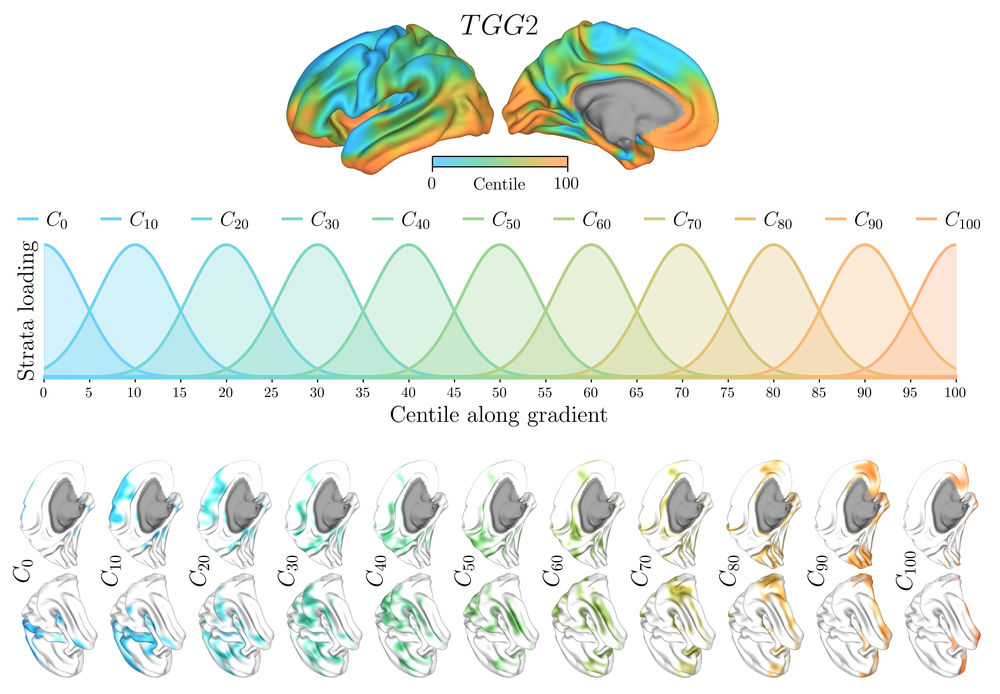

CPU times: user 17.3 s, sys: 3.88 s, total: 21.2 s
Wall time: 20.7 s


In [34]:
%%time

# save path
store_dir='/mountpoint/code/projects/normative_brain_charts/figs/R1'

fig = plt.figure(figsize=(12, 9))
fig.tight_layout(h_pad=0)
# fig.suptitle(r"\textbf{Brain eigenmodes}", fontsize=36, x=0.5, y=0.96, weight='bold', ha="center")

gs = GridSpec(3, 11, figure=fig, height_ratios=[0.9,0.7,1.4], width_ratios=[1]*11, wspace=0.01, hspace=0.3, top=0.85)  # left=0.2, bottom=0.2, right=0.8, top=0.8, 

# Show TGG2
ax = fig.add_subplot(gs[0, :])
image_path = f'{store_dir}/subfigs/gradients/TGG2_centiles_left_projection.png'
image = mpimg.imread(image_path)
ax.imshow(image)
ax.text(0.5, 0.9, rf"$TGG2$", transform=ax.transAxes, fontsize=20, ha='center', va='center')
ax.axis('off')

cax = ax.inset_axes((0.35, 0.1, 0.3, 0.06))
cb = fig.colorbar(
    mpl.cm.ScalarMappable(
        norm=mpl.colors.Normalize(vmin=0, vmax=100),
        cmap=cc.cm.isoluminant_cgo_80_c38
    ),
    cax=cax,
    aspect=10,
    orientation='horizontal',
)
# cb.outline.set_visible(False)
cax.tick_params(labelsize=12)
cax.set_xlabel(r'Centile', fontsize=12, labelpad=-10,)
cax.set_xticks([0, 100])
cax.set_xticklabels(["0", "100"], rotation=0, fontdict={'ha':'center'})

iax = fig.add_subplot(gs[1, :])
iax.axis('off')
ax = iax.inset_axes((0.03, 0., 0.94, 1.))

x_values = np.linspace(0,100,500)
centile_strata_characteristic = np.array([gaussian_transformation(x_values, centile, sigma) for centile in centiles])
centile_strata_characteristic /= centile_strata_characteristic.max()

for i, centile in enumerate(centiles):
    y_values = centile_strata_characteristic[i]
    data_mask = y_values > -0.000001
    ax.plot(x_values[data_mask], y_values[data_mask], label=rf"$C_{{{centile:.0f}}}$", c=cc.cm.isoluminant_cgo_80_c38(centile/100)[:3], lw=2);
    # ax.scatter(x_values, y_values, label=f"{centile:.0f}", c=cc.cm.isoluminant_cgo_80_c38(centile/100)[:3], s=3);
    ax.fill_between(x_values[data_mask], y_values[data_mask], y_values[data_mask]*0, color=cc.cm.isoluminant_cgo_80_c38(centile/100)[:3], alpha=0.3);

ax.scatter(x_values, y_values*0, c=cc.cm.isoluminant_cgo_80_c38(x_values/100), s=10, zorder=20, clip_on=False, marker='|');

ax.set_xlim(0, 100)
ax.set_xticks(np.linspace(0, 100, 21))
ax.set_xlabel("Centile along gradient", fontsize=16)
ax.set_ylim(0, 1.02)
ax.set_yticks([])
ax.set_ylabel("Strata loading", fontsize=16)
ax.legend(
    loc="lower center", 
    fontsize=14,
    bbox_to_anchor=(0.5, 1.03), # (x, y) coordinates: 1.01 is just above the plot
    ncol=len(centiles),         # Number of columns (put them all in 1 row)
    borderaxespad=0,            # Removes padding between axis and legend
    handlelength=0.9,           # Reduced from 2.0 to 1.0
    columnspacing=1.65,          # Decrease this to pull columns closer
    handletextpad=0.5,          # Optional: spacing between the line/icon and the text
    frameon=False               # Optional: removes the box for a cleaner look
)

# Remove top, right, and left spines
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

# Show each strata separately
for i, centile in enumerate(centiles):
    ax = fig.add_subplot(gs[2, i])
    image_path = f'{store_dir}/subfigs/gradients/TGG2_centile_group_{i}_left_projection.png'
    image = mpimg.imread(image_path)
    ax.imshow(np.rot90(image, k=1))
    ax.text(0.1, 0.5, rf"$C_{{{centile:.0f}}}$", transform=ax.transAxes, fontsize=16, ha='center', va='center', rotation=90)
    ax.axis('off')

image_path = f'{store_dir}/combined/strata_characteristics_TGG2.png'
fig.savefig(ensure_dir(image_path), bbox_inches="tight", dpi=600)
plt.close('all')
show_image(image_path)


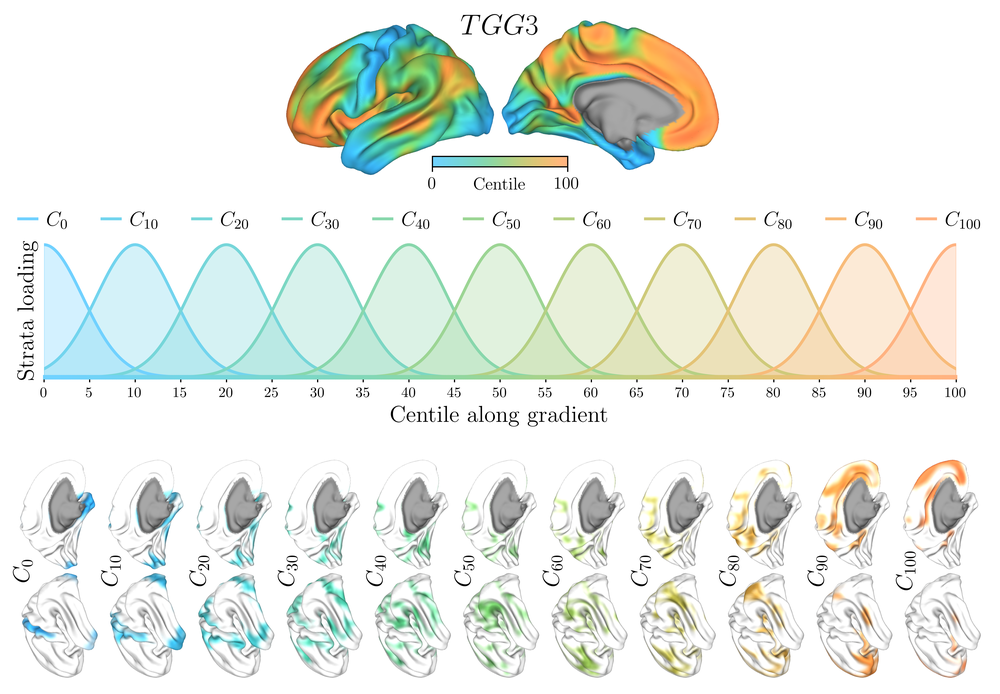

CPU times: user 17.1 s, sys: 3.03 s, total: 20.1 s
Wall time: 19.6 s


In [35]:
%%time

# save path
store_dir='/mountpoint/code/projects/normative_brain_charts/figs/R1'

fig = plt.figure(figsize=(12, 9))
fig.tight_layout(h_pad=0)
# fig.suptitle(r"\textbf{Brain eigenmodes}", fontsize=36, x=0.5, y=0.96, weight='bold', ha="center")

gs = GridSpec(3, 11, figure=fig, height_ratios=[0.9,0.7,1.4], width_ratios=[1]*11, wspace=0.01, hspace=0.3, top=0.85)  # left=0.2, bottom=0.2, right=0.8, top=0.8, 

# Show TGG2
ax = fig.add_subplot(gs[0, :])
image_path = f'{store_dir}/subfigs/gradients/TGG3_centiles_left_projection.png'
image = mpimg.imread(image_path)
ax.imshow(image)
ax.text(0.5, 0.9, rf"$TGG3$", transform=ax.transAxes, fontsize=20, ha='center', va='center')
ax.axis('off')

cax = ax.inset_axes((0.35, 0.1, 0.3, 0.06))
cb = fig.colorbar(
    mpl.cm.ScalarMappable(
        norm=mpl.colors.Normalize(vmin=0, vmax=100),
        cmap=cc.cm.isoluminant_cgo_80_c38
    ),
    cax=cax,
    aspect=10,
    orientation='horizontal',
)
# cb.outline.set_visible(False)
cax.tick_params(labelsize=12)
cax.set_xlabel(r'Centile', fontsize=12, labelpad=-10,)
cax.set_xticks([0, 100])
cax.set_xticklabels(["0", "100"], rotation=0, fontdict={'ha':'center'})

iax = fig.add_subplot(gs[1, :])
iax.axis('off')
ax = iax.inset_axes((0.03, 0., 0.94, 1.))

x_values = np.linspace(0,100,500)
centile_strata_characteristic = np.array([gaussian_transformation(x_values, centile, sigma) for centile in centiles])
centile_strata_characteristic /= centile_strata_characteristic.max()

for i, centile in enumerate(centiles):
    y_values = centile_strata_characteristic[i]
    data_mask = y_values > -0.000001
    ax.plot(x_values[data_mask], y_values[data_mask], label=rf"$C_{{{centile:.0f}}}$", c=cc.cm.isoluminant_cgo_80_c38(centile/100)[:3], lw=2);
    # ax.scatter(x_values, y_values, label=f"{centile:.0f}", c=cc.cm.isoluminant_cgo_80_c38(centile/100)[:3], s=3);
    ax.fill_between(x_values[data_mask], y_values[data_mask], y_values[data_mask]*0, color=cc.cm.isoluminant_cgo_80_c38(centile/100)[:3], alpha=0.3);

ax.scatter(x_values, y_values*0, c=cc.cm.isoluminant_cgo_80_c38(x_values/100), s=10, zorder=20, clip_on=False, marker='|');

ax.set_xlim(0, 100)
ax.set_xticks(np.linspace(0, 100, 21))
ax.set_xlabel("Centile along gradient", fontsize=16)
ax.set_ylim(0, 1.02)
ax.set_yticks([])
ax.set_ylabel("Strata loading", fontsize=16)
ax.legend(
    loc="lower center", 
    fontsize=14,
    bbox_to_anchor=(0.5, 1.03), # (x, y) coordinates: 1.01 is just above the plot
    ncol=len(centiles),         # Number of columns (put them all in 1 row)
    borderaxespad=0,            # Removes padding between axis and legend
    handlelength=0.9,           # Reduced from 2.0 to 1.0
    columnspacing=1.65,          # Decrease this to pull columns closer
    handletextpad=0.5,          # Optional: spacing between the line/icon and the text
    frameon=False               # Optional: removes the box for a cleaner look
)

# Remove top, right, and left spines
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

# Show each strata separately
for i, centile in enumerate(centiles):
    ax = fig.add_subplot(gs[2, i])
    image_path = f'{store_dir}/subfigs/gradients/TGG3_centile_group_{i}_left_projection.png'
    image = mpimg.imread(image_path)
    ax.imshow(np.rot90(image, k=1))
    ax.text(0.1, 0.5, rf"$C_{{{centile:.0f}}}$", transform=ax.transAxes, fontsize=16, ha='center', va='center', rotation=90)
    ax.axis('off')

image_path = f'{store_dir}/combined/strata_characteristics_TGG3.png'
fig.savefig(ensure_dir(image_path), bbox_inches="tight", dpi=600)
plt.close('all')
show_image(image_path)


## Generate lifespan normative charts along gradients 

---



In [36]:
# For the centile groups created in the previous cells, we can generate associated growth charts:
for brain_map in tqdm(selected_gradients):
    centile_group_queries_encoded = eigenmode_basis.encode(average_operator(brain_maps[brain_map]["Centile Groups"]), n_modes=1000)
    # predict moments
    gradient_moments = spectral_normative_model.predict(
        encoded_query=centile_group_queries_encoded.T,
        test_covariates=pd.DataFrame({"age": candidate_ages,}),
        predict_without=['site', 'sex'],
        n_modes=1000, # to simplify the inference
    ).predictions
    gradient_moments_plus = spectral_normative_model.predict(
        encoded_query=centile_group_queries_encoded.T,
        test_covariates=pd.DataFrame({"age": candidate_ages + dt,}),
        predict_without=['site', 'sex'],
        n_modes=1000, # to simplify the inference
    ).predictions
    gradient_moments_minus = spectral_normative_model.predict(
        encoded_query=centile_group_queries_encoded.T,
        test_covariates=pd.DataFrame({"age": candidate_ages - dt,}),
        predict_without=['site', 'sex'],
        n_modes=1000, # to simplify the inference
    ).predictions
    gradient_rate = (gradient_moments_plus['mu_estimate'] - gradient_moments_minus['mu_estimate']) / (2 * dt)
    # store predicted charts
    brain_maps[brain_map]["Centile Group Charts"] = {'moments': gradient_moments, 'rate': gradient_rate}


  0%|          | 0/6 [00:00<?, ?it/s]

Computing direct eigenmode estimates:   0%|          | 0/1000 [00:00<?, ?tasks/s]

Computing cross-mode dependence estimates:   0%|          | 0/4889 [00:00<?, ?tasks/s]

Computing direct eigenmode estimates:   0%|          | 0/1000 [00:00<?, ?tasks/s]

Computing cross-mode dependence estimates:   0%|          | 0/4889 [00:00<?, ?tasks/s]

...

Computing cross-mode dependence estimates:   0%|          | 0/4889 [00:00<?, ?tasks/s]

Computing direct eigenmode estimates:   0%|          | 0/1000 [00:00<?, ?tasks/s]

Computing cross-mode dependence estimates:   0%|          | 0/4889 [00:00<?, ?tasks/s]

Computing direct eigenmode estimates:   0%|          | 0/1000 [00:00<?, ?tasks/s]

Computing cross-mode dependence estimates:   0%|          | 0/4889 [00:00<?, ?tasks/s]

### Gradient strata charts figure

---

Let's visualize the normative charts along strata.


In [37]:
test_spectral_basis_predictions_store_path = f'/mountpoint/code/projects/normative_brain_charts/data/predictions/spectral_basis/test:spectral_basis_predictions.joblib'
test_spectral_basis_predictions = joblib.load(test_spectral_basis_predictions_store_path, mmap_mode="r")

partial_test_spectral_basis_predictions_store_path = f'/mountpoint/code/projects/normative_brain_charts/data/predictions/spectral_basis/partial_test:spectral_basis_predictions.joblib'
partial_test_spectral_basis_predictions = joblib.load(partial_test_spectral_basis_predictions_store_path, mmap_mode="r")


In [38]:
n_k=1000
centile_group_queries_encoded = eigenmode_basis.encode(average_operator(brain_maps["TGG1"]["Centile Groups"]), n_modes=1000)
harmonized_spectral_coefficients = spectral_normative_model.harmonize(
    encoded_query=centile_group_queries_encoded[:, :n_k].T,
    spectral_predictions_full=test_spectral_basis_predictions,
    spectral_predictions_partial=partial_test_spectral_basis_predictions,
    spectral_coeff_data=test_spectral_coefficients[:, :n_k],
    n_modes=n_k, # to simplify the inference
)

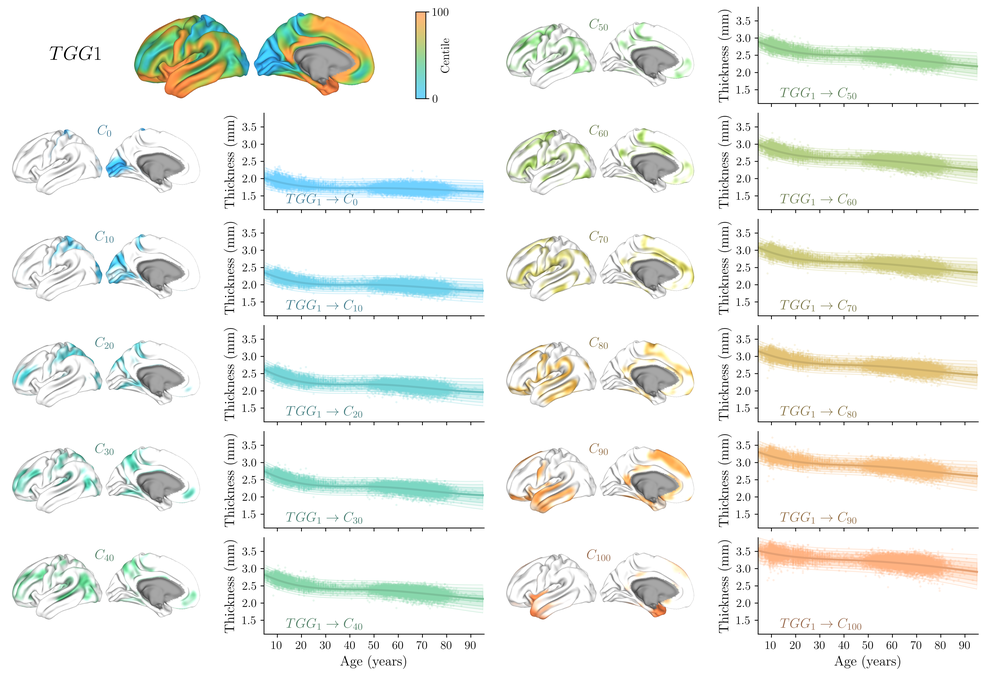

CPU times: user 19.1 s, sys: 9.94 s, total: 29.1 s
Wall time: 27.9 s


In [39]:
%%time

def plot_spectral_reconstruction_charts(fig, ax, brain_map, group_idx, show_x_ticklabels=True):
    
    # predict moments
    predicted_spectral_moments = brain_maps[brain_map]["Centile Group Charts"]["moments"]
    
    # extract predicted moments
    y_ppc_mu_mean = predicted_spectral_moments['mu_estimate'][:, group_idx]
    y_ppc_sigma_mean = predicted_spectral_moments['std_estimate'][:, group_idx]

    quantiles = [0.001, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 0.999]

    thickness_quantiles = {
        q: (
            (
                y_ppc_mu_mean + stats.norm.ppf(q=q) * (y_ppc_sigma_mean)
            )
        ) for q in quantiles
    }

    # colors for the plot
    c=cc.cm.isoluminant_cgo_80_c38(centiles[group_idx]/100)[:3]
    # c1 = '#448e9c'  # brighter shade
    c1 = c  # brighter shade
    # c2 = '#038da6'  # darker shade
    c2 = (np.array(c)*0.9)  # darker shade

    tmp_df = demography_df[demography_df["split"] == "Test"].copy()
    tmp_df['harmonized_thickness'] = harmonized_spectral_coefficients[:, group_idx]

    sns.scatterplot(
        data=tmp_df,
        x='age',
        y='harmonized_thickness',
        ax=ax,
        linewidth=0,
        # hue='sex',
        # palette="colorblind",
        alpha = 0.2,
        s=5,
        # c="#777",
        color=c1,
        zorder=-20,
    )

    # centile plots
    for q1, q2, alpha in [(0.001, 0.999, 0.05), (0.01, 0.99, 0.1), (0.05, 0.95, 0.2), (0.25, 0.75, 0.3)]:
        ax.fill_between(
            candidate_ages,
            thickness_quantiles[q1],
            thickness_quantiles[q2],
            alpha=alpha,
            color=c1,
        )

        # Now add boundary lines with different colors
        ax.plot(candidate_ages, thickness_quantiles[q1], color=c1, lw=0.5, linestyle=":",)
        ax.plot(candidate_ages, thickness_quantiles[q2], color=c1, lw=0.5, linestyle=":",)

    # Median
    ax.plot(
        candidate_ages,
        thickness_quantiles[0.5],
        c=c2,
        lw=2,
    )

    ax.tick_params(axis='both', labelsize=12)

    ax.set_xlim(4.5,95.5)
    ax.set_xticks(np.linspace(10, 90, 9))
    ax.set_ylim(1.1,3.9)
    ax.set_yticks(np.linspace(1.5, 3.5, 5))
    # ax.set_xlabel("Age (years)", fontsize=24, labelpad=15)
    ax.set_xlabel("Age (years)", fontsize=14)
    if not show_x_ticklabels:
        ax.set_xticklabels(['']*9)
        ax.set_xlabel("")
    ax.set_ylabel(r"Thickness (mm)", fontsize=14, labelpad=5)
    # ax.grid(True, color='gray', alpha=0.3, linestyle=':')

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.text(0.1, 0.1, rf"$TGG_1 \rightarrow C_{{{centile:.0f}}}$", transform=ax.transAxes, fontsize=14, ha='left', va='center', rotation=0, c=(np.array(c)*0.6))

# save path
store_dir='/mountpoint/code/projects/normative_brain_charts/figs/R1'

fig = plt.figure(figsize=(18, 12))
fig.tight_layout(h_pad=0)
# fig.suptitle(r"\textbf{Brain eigenmodes}", fontsize=36, x=0.5, y=0.96, weight='bold', ha="center")

rows, cols = 6, 4
height_ratios=[1]*rows
width_ratios=[1]*cols
width_ratios=[1, 1.5]*2
gs = GridSpec(rows, cols, figure=fig, height_ratios=height_ratios, width_ratios=width_ratios, wspace=0.01, hspace=0.1, top=0.85)  # left=0.2, bottom=0.2, right=0.8, top=0.8, 

# Show each strata separately
for i, centile in enumerate(centiles):
    # color for the plot
    c=cc.cm.isoluminant_cgo_80_c38(centile/100)[:3]
    ax = fig.add_subplot(gs[(i+1)%6, 2*((i+1)//6)])
    image_path = f'{store_dir}/subfigs/gradients/TGG1_centile_group_{i}_left_projection.png'
    image = mpimg.imread(image_path)
    ax.imshow(image)
    ax.text(0.5, 0.9, rf"$C_{{{centile:.0f}}}$", transform=ax.transAxes, fontsize=14, ha='center', va='center', rotation=0, c=(np.array(c)*0.6))
    ax.set_xticks([])
    ax.set_yticks([])
    ax.axis('off')

# Show normative trajectory of each strata separately
for i, centile in enumerate(centiles):
    iax = fig.add_subplot(gs[(i+1)%6, 1 + 2*((i+1)//6)])
    iax.axis('off')
    ax = iax.inset_axes((0.2, 0., 0.75, 1.))
    plot_spectral_reconstruction_charts(fig, ax, "TGG1", i, show_x_ticklabels=(i==4 or i==10))

# Show TGG2
ax = fig.add_subplot(gs[0, :2])
image_path = f'{store_dir}/subfigs/gradients/TGG1_centiles_left_projection.png'
image = mpimg.imread(image_path)
ax.imshow(image)
ax.text(-0.1, 0.5, rf"$TGG1$", transform=ax.transAxes, fontsize=20, ha='right', va='center')
ax.axis('off')

cax = ax.inset_axes((1.15, 0.05, 0.04, 0.9))
cb = fig.colorbar(
    mpl.cm.ScalarMappable(
        norm=mpl.colors.Normalize(vmin=0, vmax=100),
        cmap=cc.cm.isoluminant_cgo_80_c38
    ),
    cax=cax,
    aspect=10,
    orientation='vertical',
)
# cb.outline.set_visible(False)
cax.tick_params(labelsize=12)
cax.set_ylabel(r'Centile', fontsize=12, labelpad=-9,)
cax.set_yticks([0, 100])
cax.set_yticklabels(["0", "100"], rotation=0, fontdict={'ha':'left'})

image_path = f'{store_dir}/combined/strata_charts_TGG1.png'
fig.savefig(ensure_dir(image_path), bbox_inches="tight", dpi=600)
plt.close('all')
show_image(image_path)



In [40]:
n_k=1000
centile_group_queries_encoded = eigenmode_basis.encode(average_operator(brain_maps["TGG2"]["Centile Groups"]), n_modes=1000)
harmonized_spectral_coefficients = spectral_normative_model.harmonize(
    encoded_query=centile_group_queries_encoded[:, :n_k].T,
    spectral_predictions_full=test_spectral_basis_predictions,
    spectral_predictions_partial=partial_test_spectral_basis_predictions,
    spectral_coeff_data=test_spectral_coefficients[:, :n_k],
    n_modes=n_k, # to simplify the inference
)

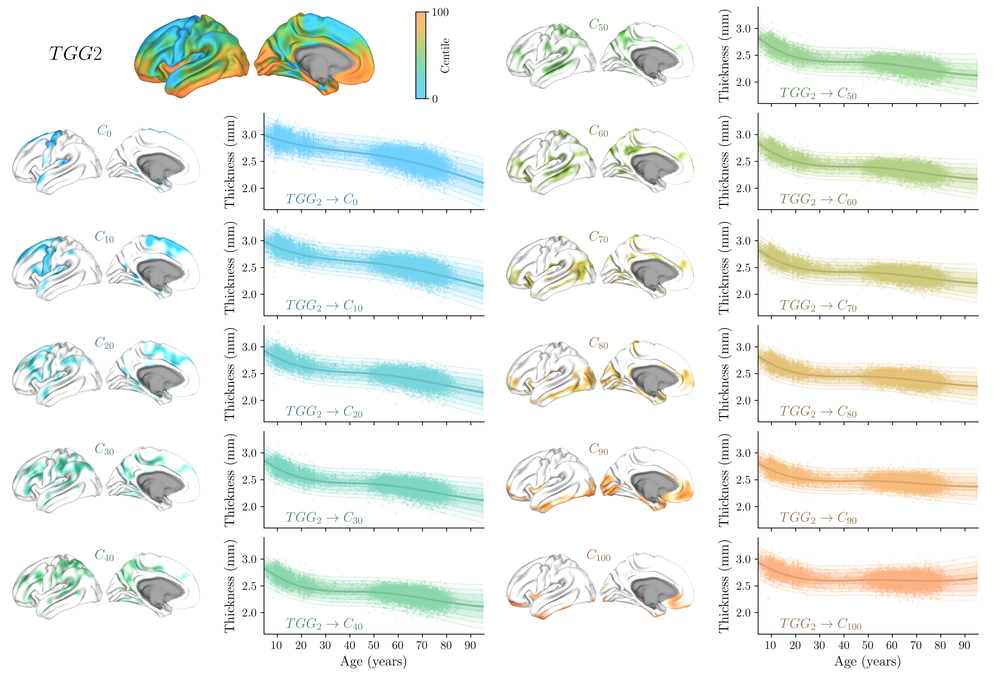

CPU times: user 20.2 s, sys: 3.2 s, total: 23.4 s
Wall time: 22.7 s


In [41]:
%%time

def plot_spectral_reconstruction_charts(fig, ax, brain_map, group_idx, show_x_ticklabels=True):
    
    # predict moments
    predicted_spectral_moments = brain_maps[brain_map]["Centile Group Charts"]["moments"]
    
    # extract predicted moments
    y_ppc_mu_mean = predicted_spectral_moments['mu_estimate'][:, group_idx]
    y_ppc_sigma_mean = predicted_spectral_moments['std_estimate'][:, group_idx]

    quantiles = [0.001, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 0.999]

    thickness_quantiles = {
        q: (
            (
                y_ppc_mu_mean + stats.norm.ppf(q=q) * (y_ppc_sigma_mean)
            )
        ) for q in quantiles
    }

    # colors for the plot
    c=cc.cm.isoluminant_cgo_80_c38(centiles[group_idx]/100)[:3]
    # c1 = '#448e9c'  # brighter shade
    c1 = c  # brighter shade
    # c2 = '#038da6'  # darker shade
    c2 = (np.array(c)*0.9)  # darker shade

    tmp_df = demography_df[demography_df["split"] == "Test"].copy()
    tmp_df['harmonized_thickness'] = harmonized_spectral_coefficients[:, group_idx]

    sns.scatterplot(
        data=tmp_df,
        x='age',
        y='harmonized_thickness',
        ax=ax,
        linewidth=0,
        # hue='sex',
        # palette="colorblind",
        alpha = 0.2,
        s=5,
        # c="#777",
        color=c1,
        zorder=-20,
    )

    # centile plots
    for q1, q2, alpha in [(0.001, 0.999, 0.05), (0.01, 0.99, 0.1), (0.05, 0.95, 0.2), (0.25, 0.75, 0.3)]:
        ax.fill_between(
            candidate_ages,
            thickness_quantiles[q1],
            thickness_quantiles[q2],
            alpha=alpha,
            color=c1,
        )

        # Now add boundary lines with different colors
        ax.plot(candidate_ages, thickness_quantiles[q1], color=c1, lw=0.5, linestyle=":",)
        ax.plot(candidate_ages, thickness_quantiles[q2], color=c1, lw=0.5, linestyle=":",)

    # Median
    ax.plot(
        candidate_ages,
        thickness_quantiles[0.5],
        c=c2,
        lw=2,
    )

    ax.tick_params(axis='both', labelsize=12)

    ax.set_xlim(4.5,95.5)
    ax.set_xticks(np.linspace(10, 90, 9))
    ax.set_ylim(1.6,3.4)
    ax.set_yticks(np.linspace(2.0, 3.0, 3))
    # ax.set_xlabel("Age (years)", fontsize=24, labelpad=15)
    ax.set_xlabel("Age (years)", fontsize=14)
    if not show_x_ticklabels:
        ax.set_xticklabels(['']*9)
        ax.set_xlabel("")
    ax.set_ylabel(r"Thickness (mm)", fontsize=14, labelpad=5)
    # ax.grid(True, color='gray', alpha=0.3, linestyle=':')

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.text(0.1, 0.1, rf"$TGG_2 \rightarrow C_{{{centile:.0f}}}$", transform=ax.transAxes, fontsize=14, ha='left', va='center', rotation=0, c=(np.array(c)*0.6))

# save path
store_dir='/mountpoint/code/projects/normative_brain_charts/figs/R1'

fig = plt.figure(figsize=(18, 12))
fig.tight_layout(h_pad=0)
# fig.suptitle(r"\textbf{Brain eigenmodes}", fontsize=36, x=0.5, y=0.96, weight='bold', ha="center")

rows, cols = 6, 4
height_ratios=[1]*rows
width_ratios=[1]*cols
width_ratios=[1, 1.5]*2
gs = GridSpec(rows, cols, figure=fig, height_ratios=height_ratios, width_ratios=width_ratios, wspace=0.01, hspace=0.1, top=0.85)  # left=0.2, bottom=0.2, right=0.8, top=0.8, 

# Show each strata separately
for i, centile in enumerate(centiles):
    # color for the plot
    c=cc.cm.isoluminant_cgo_80_c38(centile/100)[:3]
    ax = fig.add_subplot(gs[(i+1)%6, 2*((i+1)//6)])
    image_path = f'{store_dir}/subfigs/gradients/TGG2_centile_group_{i}_left_projection.png'
    image = mpimg.imread(image_path)
    ax.imshow(image)
    ax.text(0.5, 0.9, rf"$C_{{{centile:.0f}}}$", transform=ax.transAxes, fontsize=14, ha='center', va='center', rotation=0, c=(np.array(c)*0.6))
    ax.set_xticks([])
    ax.set_yticks([])
    ax.axis('off')

# Show normative trajectory of each strata separately
for i, centile in enumerate(centiles):
    iax = fig.add_subplot(gs[(i+1)%6, 1 + 2*((i+1)//6)])
    iax.axis('off')
    ax = iax.inset_axes((0.2, 0., 0.75, 1.))
    plot_spectral_reconstruction_charts(fig, ax, "TGG2", i, show_x_ticklabels=(i==4 or i==10))

# Show TGG2
ax = fig.add_subplot(gs[0, :2])
image_path = f'{store_dir}/subfigs/gradients/TGG2_centiles_left_projection.png'
image = mpimg.imread(image_path)
ax.imshow(image)
ax.text(-0.1, 0.5, rf"$TGG2$", transform=ax.transAxes, fontsize=20, ha='right', va='center')
ax.axis('off')

cax = ax.inset_axes((1.15, 0.05, 0.04, 0.9))
cb = fig.colorbar(
    mpl.cm.ScalarMappable(
        norm=mpl.colors.Normalize(vmin=0, vmax=100),
        cmap=cc.cm.isoluminant_cgo_80_c38
    ),
    cax=cax,
    aspect=10,
    orientation='vertical',
)
# cb.outline.set_visible(False)
cax.tick_params(labelsize=12)
cax.set_ylabel(r'Centile', fontsize=12, labelpad=-9,)
cax.set_yticks([0, 100])
cax.set_yticklabels(["0", "100"], rotation=0, fontdict={'ha':'left'})

image_path = f'{store_dir}/combined/strata_charts_TGG2.png'
fig.savefig(ensure_dir(image_path), bbox_inches="tight", dpi=600)
plt.close('all')
show_image(image_path)



In [42]:
n_k=1000
centile_group_queries_encoded = eigenmode_basis.encode(average_operator(brain_maps["TGG3"]["Centile Groups"]), n_modes=1000)
harmonized_spectral_coefficients = spectral_normative_model.harmonize(
    encoded_query=centile_group_queries_encoded[:, :n_k].T,
    spectral_predictions_full=test_spectral_basis_predictions,
    spectral_predictions_partial=partial_test_spectral_basis_predictions,
    spectral_coeff_data=test_spectral_coefficients[:, :n_k],
    n_modes=n_k, # to simplify the inference
)

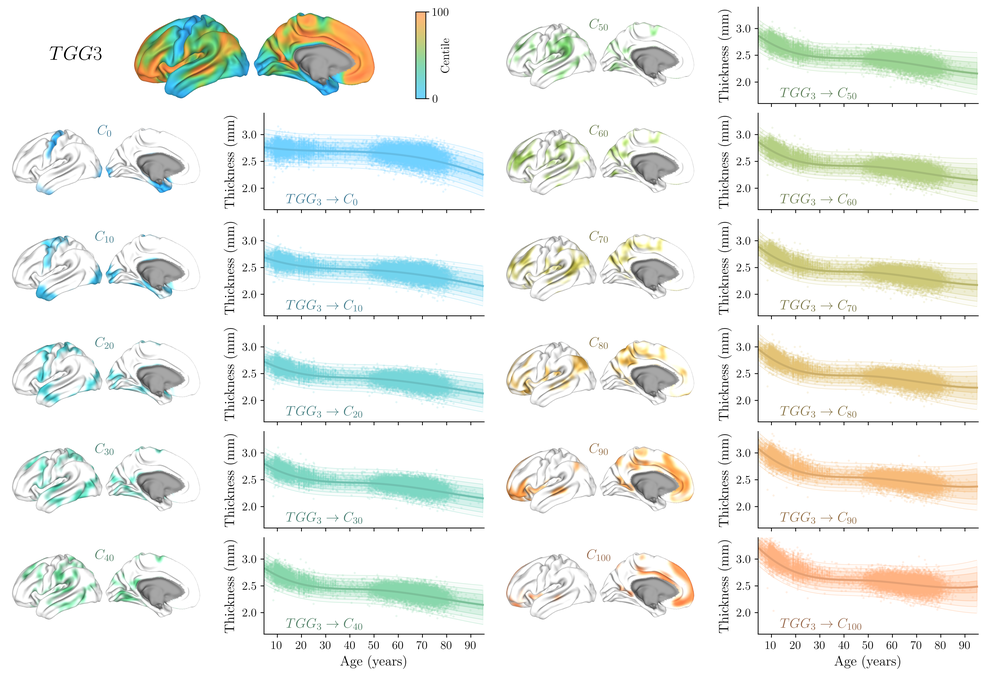

CPU times: user 19.7 s, sys: 3.84 s, total: 23.5 s
Wall time: 22 s


In [43]:
%%time

def plot_spectral_reconstruction_charts(fig, ax, brain_map, group_idx, show_x_ticklabels=True):
    
    # predict moments
    predicted_spectral_moments = brain_maps[brain_map]["Centile Group Charts"]["moments"]
    
    # extract predicted moments
    y_ppc_mu_mean = predicted_spectral_moments['mu_estimate'][:, group_idx]
    y_ppc_sigma_mean = predicted_spectral_moments['std_estimate'][:, group_idx]

    quantiles = [0.001, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 0.999]

    thickness_quantiles = {
        q: (
            (
                y_ppc_mu_mean + stats.norm.ppf(q=q) * (y_ppc_sigma_mean)
            )
        ) for q in quantiles
    }

    # colors for the plot
    c=cc.cm.isoluminant_cgo_80_c38(centiles[group_idx]/100)[:3]
    # c1 = '#448e9c'  # brighter shade
    c1 = c  # brighter shade
    # c2 = '#038da6'  # darker shade
    c2 = (np.array(c)*0.9)  # darker shade

    tmp_df = demography_df[demography_df["split"] == "Test"].copy()
    tmp_df['harmonized_thickness'] = harmonized_spectral_coefficients[:, group_idx]

    sns.scatterplot(
        data=tmp_df,
        x='age',
        y='harmonized_thickness',
        ax=ax,
        linewidth=0,
        # hue='sex',
        # palette="colorblind",
        alpha = 0.2,
        s=5,
        # c="#777",
        color=c1,
        zorder=-20,
    )

    # centile plots
    for q1, q2, alpha in [(0.001, 0.999, 0.05), (0.01, 0.99, 0.1), (0.05, 0.95, 0.2), (0.25, 0.75, 0.3)]:
        ax.fill_between(
            candidate_ages,
            thickness_quantiles[q1],
            thickness_quantiles[q2],
            alpha=alpha,
            color=c1,
        )

        # Now add boundary lines with different colors
        ax.plot(candidate_ages, thickness_quantiles[q1], color=c1, lw=0.5, linestyle=":",)
        ax.plot(candidate_ages, thickness_quantiles[q2], color=c1, lw=0.5, linestyle=":",)

    # Median
    ax.plot(
        candidate_ages,
        thickness_quantiles[0.5],
        c=c2,
        lw=2,
    )

    ax.tick_params(axis='both', labelsize=12)

    ax.set_xlim(4.5,95.5)
    ax.set_xticks(np.linspace(10, 90, 9))
    ax.set_ylim(1.6,3.4)
    ax.set_yticks(np.linspace(2.0, 3.0, 3))
    # ax.set_xlabel("Age (years)", fontsize=24, labelpad=15)
    ax.set_xlabel("Age (years)", fontsize=14)
    if not show_x_ticklabels:
        ax.set_xticklabels(['']*9)
        ax.set_xlabel("")
    ax.set_ylabel(r"Thickness (mm)", fontsize=14, labelpad=5)
    # ax.grid(True, color='gray', alpha=0.3, linestyle=':')

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.text(0.1, 0.1, rf"$TGG_3 \rightarrow C_{{{centile:.0f}}}$", transform=ax.transAxes, fontsize=14, ha='left', va='center', rotation=0, c=(np.array(c)*0.6))

# save path
store_dir='/mountpoint/code/projects/normative_brain_charts/figs/R1'

fig = plt.figure(figsize=(18, 12))
fig.tight_layout(h_pad=0)
# fig.suptitle(r"\textbf{Brain eigenmodes}", fontsize=36, x=0.5, y=0.96, weight='bold', ha="center")

rows, cols = 6, 4
height_ratios=[1]*rows
width_ratios=[1]*cols
width_ratios=[1, 1.5]*2
gs = GridSpec(rows, cols, figure=fig, height_ratios=height_ratios, width_ratios=width_ratios, wspace=0.01, hspace=0.1, top=0.85)  # left=0.2, bottom=0.2, right=0.8, top=0.8, 

# Show each strata separately
for i, centile in enumerate(centiles):
    # color for the plot
    c=cc.cm.isoluminant_cgo_80_c38(centile/100)[:3]
    ax = fig.add_subplot(gs[(i+1)%6, 2*((i+1)//6)])
    image_path = f'{store_dir}/subfigs/gradients/TGG3_centile_group_{i}_left_projection.png'
    image = mpimg.imread(image_path)
    ax.imshow(image)
    ax.text(0.5, 0.9, rf"$C_{{{centile:.0f}}}$", transform=ax.transAxes, fontsize=14, ha='center', va='center', rotation=0, c=(np.array(c)*0.6))
    ax.set_xticks([])
    ax.set_yticks([])
    ax.axis('off')

# Show normative trajectory of each strata separately
for i, centile in enumerate(centiles):
    iax = fig.add_subplot(gs[(i+1)%6, 1 + 2*((i+1)//6)])
    iax.axis('off')
    ax = iax.inset_axes((0.2, 0., 0.75, 1.))
    plot_spectral_reconstruction_charts(fig, ax, "TGG3", i, show_x_ticklabels=(i==4 or i==10))

# Show TGG2
ax = fig.add_subplot(gs[0, :2])
image_path = f'{store_dir}/subfigs/gradients/TGG3_centiles_left_projection.png'
image = mpimg.imread(image_path)
ax.imshow(image)
ax.text(-0.1, 0.5, rf"$TGG3$", transform=ax.transAxes, fontsize=20, ha='right', va='center')
ax.axis('off')

cax = ax.inset_axes((1.15, 0.05, 0.04, 0.9))
cb = fig.colorbar(
    mpl.cm.ScalarMappable(
        norm=mpl.colors.Normalize(vmin=0, vmax=100),
        cmap=cc.cm.isoluminant_cgo_80_c38
    ),
    cax=cax,
    aspect=10,
    orientation='vertical',
)
# cb.outline.set_visible(False)
cax.tick_params(labelsize=12)
cax.set_ylabel(r'Centile', fontsize=12, labelpad=-9,)
cax.set_yticks([0, 100])
cax.set_yticklabels(["0", "100"], rotation=0, fontdict={'ha':'left'})

image_path = f'{store_dir}/combined/strata_charts_TGG3.png'
fig.savefig(ensure_dir(image_path), bbox_inches="tight", dpi=600)
plt.close('all')
show_image(image_path)



## Subfigure: Thickness growth gradients

---



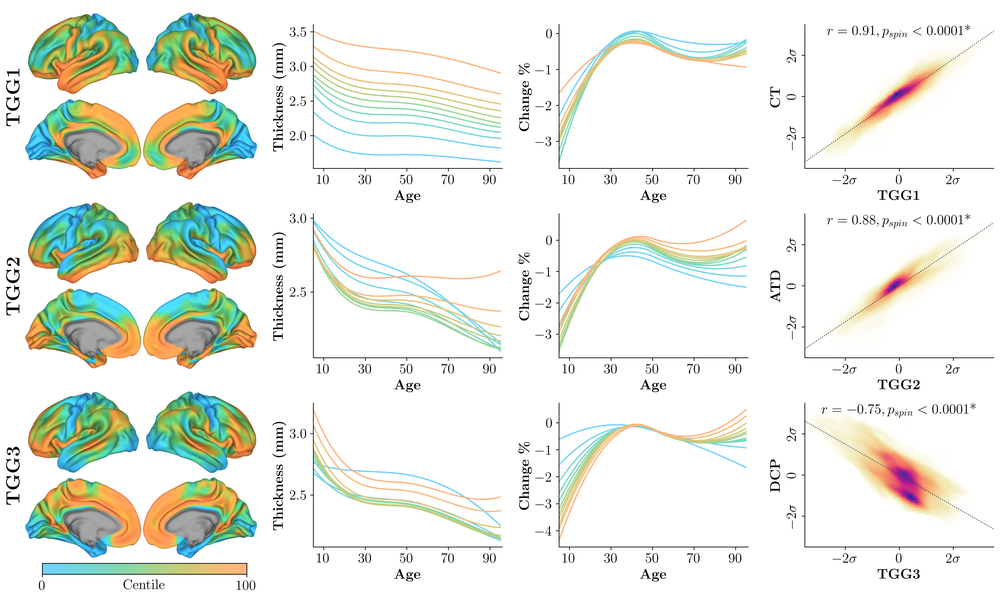

CPU times: user 1min 44s, sys: 2.28 s, total: 1min 46s
Wall time: 1min 31s


In [44]:
%%time
%matplotlib agg

# save path
store_dir='/mountpoint/code/projects/normative_brain_charts/figs/R1'

fig = plt.figure(figsize=(20, 12))
fig.tight_layout(h_pad=0)

outer_gs = gridspec.GridSpec(3, 2, figure=fig, width_ratios=[1.1, 3], wspace=0.1, hspace=0.05, top=0.85)

# TGCs
for i in range(3):
    ax = fig.add_subplot(outer_gs[i, 0])
    ax.text(-0.01, 0.5, rf"\textbf{{TGG{{{i+1}}}}}", transform=ax.transAxes, fontsize=22, ha='center', va='center', rotation=90)
    ax.axis('off')
    iax = ax.inset_axes((0, 0., 1, 1.))
    iax.imshow(mpimg.imread(f'{store_dir}/subfigs/gradients/TGG{i+1}_centiles_projection.png'))
    iax.axis('off')
    if i == 2:
        cax = ax.inset_axes((0.1, -0.05, 0.82, 0.06))
        
        cb = fig.colorbar(
            mpl.cm.ScalarMappable(
                norm=mpl.colors.Normalize(vmin=0, vmax=100),
                cmap=cc.cm.isoluminant_cgo_80_c38
            ),
            cax=cax,
            aspect=10,
            orientation='horizontal',
        )
        cax.tick_params(labelsize=16)
        cax.set_xlabel(r'Centile', fontsize=16, labelpad=-15,)
        cax.set_xticks([0, 100])
        cax.set_xticklabels(["0", "100"], rotation=0, fontdict={'ha':'center'})


# Centile Group Charts
map_pairs = [("TGG1", "CT"), ("TGG2", "ATD"), ("TGG3", "DCP")]
for i in range(3):
    inner = gridspec.GridSpecFromSubplotSpec(3, 3, height_ratios=[1,19,1], subplot_spec=outer_gs[i, 1], wspace=0.3, hspace=0.2)

    # mean thickness
    ax = fig.add_subplot(inner[1, 0])
    ax.set_yticks([2, 2.5, 3, 3.5])
    ax.set_xlim(5, 96)
    ax.set_xticks([10, 30, 50, 70, 90])
    ax.tick_params(labelsize=16)
    for j, centile in enumerate(centiles):
        ax.plot(
            candidate_ages,
            brain_maps[f"TGG{i+1}"]["Centile Group Charts"]['moments']['mu_estimate'][:,j],
            c=cc.cm.isoluminant_cgo_80_c38(centile/100)[:3],
        )
    ax.set_xlabel(r'\textbf{Age}', fontsize=16)
    ax.set_ylabel(r"\textbf{Thickness (mm)}", fontsize=16,)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    # % change
    ax = fig.add_subplot(inner[1, 1])
    ax.set_yticks([0, -1, -2, -3, -4])
    ax.set_xlim(5, 96)
    ax.set_xticks([10, 30, 50, 70, 90])
    ax.tick_params(labelsize=16)
    for j, centile in enumerate(centiles):
        ax.plot(
            candidate_ages,
            brain_maps[f"TGG{i+1}"]["Centile Group Charts"]['rate'][:,j]*100,
            c=cc.cm.isoluminant_cgo_80_c38(centile/100)[:3],
        )
    ax.set_xlabel(r'\textbf{Age}', fontsize=16)
    ax.set_ylabel(r"\textbf{Change \%}", fontsize=16,)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    # correspondence
    ax = fig.add_subplot(inner[1, 2])
    # Compute point density
    x = (brain_maps[map_pairs[i][0]]["map"]).copy()
    y = (brain_maps[map_pairs[i][1]]["map"]).copy()
    xy = np.vstack([x, y])
    z = stats.gaussian_kde(xy)(xy)
    # axis limits
    x_mean, x_std, y_mean, y_std= x.mean(), x.std(), y.mean(), y.std()
    ax.set_xlim(x_mean - 3.5 * x_std, x_mean + 3.5 * x_std)
    ax.set_ylim(y_mean - 3.5 * y_std, y_mean + 3.5 * y_std)
    ax.set_xticks([x_mean - 2 * x_std, x_mean, x_mean + 2 * x_std])
    ax.set_xticklabels([r"$-2\sigma$", r"$0$", r"$2\sigma$"])
    ax.set_yticks([y_mean - 2 * y_std, y_mean, y_mean + 2 * y_std])
    ax.set_yticklabels([r"$-2\sigma$", r"$0$", r"$2\sigma$"], rotation=90, fontdict={'va':'center'})
    ax.scatter(x, y, c=z, s=1, cmap=cc.cm.linear_worb_100_25_c53)
    ax.set_xlabel(rf'\textbf{{{map_pairs[i][0]}}}', fontsize=16)
    ax.set_ylabel(rf'\textbf{{{map_pairs[i][1]}}}', fontsize=16)
    # Regression line
    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x_mean - 4 * x_std, x_mean + 4 * x_std, 2)
    ax.plot(x_line, m * x_line + b, color='#333', linewidth=1, linestyle=':')
    ax.tick_params(labelsize=16)
    r = np.corrcoef(x,y)[0,1]
    ax.text(0.5, 0.95, rf"$r={{{r:.2f}}},p_{{spin}}<0.0001$*", transform=ax.transAxes, fontsize=16, ha='center', va='center', rotation=0)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

image_path = f'{store_dir}/combined/thickness_growth_components_part_1.png'
fig.savefig(ensure_dir(image_path), bbox_inches="tight", dpi=600)
plt.close('all')
show_image(image_path)


In [45]:
# To verify statistics
map_list = [x for x in brain_maps]
pvals=[]
for map_pair in map_pairs:
    idx1 = map_list.index(map_pair[0])
    idx2 = map_list.index(map_pair[1])
    print(
        map_pair,
        triu_vector_to_symmetric_matrix(network_stats['corellation r'])[idx1, idx2],
        triu_vector_to_symmetric_matrix(network_stats['non-parametric p-val'])[idx1, idx2],
    )
    pvals.append(triu_vector_to_symmetric_matrix(network_stats['non-parametric p-val'])[idx1, idx2])

print("FDR corrected pvalues", multipletests(pvals, method='fdr_bh')[1])

('TGG1', 'CT') 0.9094423586314802 4.999750012499375e-05
('TGG2', 'ATD') 0.8760806657379496 4.999750012499375e-05
('TGG3', 'DCP') -0.7506931519568607 4.999750012499375e-05
FDR corrected pvalues [4.99975001e-05 4.99975001e-05 4.99975001e-05]


## Subfigure: Data-driven brain map comparison

---



In [46]:
# Flip maps to optimally align with Thickness Growth Components

# Load correlations
correlations = triu_vector_to_symmetric_matrix(network_stats['corellation r'])
np.fill_diagonal(correlations, 1)

# Indices of TGG1, TGG2, TGG3
tgg_indices = [map_list.index(label) for label in ['TGG1', 'TGG2', 'TGG3']]

# --- Greedy iterative flipping based only on TGG correlations ---
n = correlations.shape[0]
flips = np.ones(n)
rows_checked = np.zeros(n, dtype=bool)
iterations = 0

while not np.all(rows_checked):
    for i in range(n):
        if rows_checked[i]:
            continue
        # Effective correlations with TGG maps
        row = correlations[i, tgg_indices] * flips[i] * flips[tgg_indices]
        # Flip if the largest absolute correlation among TGGs is negative
        jmax = np.argmax(np.abs(row))
        if row[jmax] < 0:
            flips[i] *= -1
            rows_checked[:] = False  # restart from the top
            break
        else:
            rows_checked[i] = True
    iterations += 1
    if iterations > n * 2:  # safety
        break

flipped_correlations = np.diag(flips) @ correlations @ np.diag(flips)
similarities = (flipped_correlations + 1) / 2

# --- Cluster maps ---
n_clusters = 3
clustering = sklearn.cluster.SpectralClustering(
    n_clusters=n_clusters,
    affinity='precomputed',  # because we already have similarities
    assign_labels='kmeans',
    random_state=42
).fit(similarities)

cluster_labels = {i: x for i, x in enumerate(clustering.labels_)}
cluster_labels

# --- Extract hierarchical structure
ytdist = spatial.distance.squareform(1 - similarities)
Z = hierarchy.linkage(ytdist, 'single', optimal_ordering=False)

# --- Update the order of maps to align with clusters and hierarchy ---
map_list = list(brain_maps)
ordered_labels = ['TGG1', 'CT', 'GEC1', 'SA', 'FCG1', 'GEC3',
                  'TGG3', 'DCP', 'GEC2', 'FCG2', 'TGG2', 'ATD']
reordering = np.array([map_list.index(x) for x in ordered_labels], dtype=int)


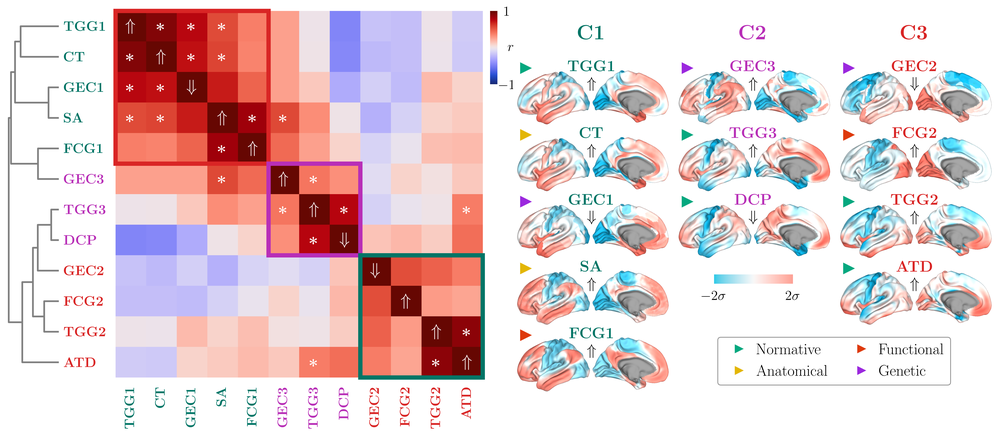

CPU times: user 18 s, sys: 3.02 s, total: 21 s
Wall time: 20.4 s


In [47]:
%%time
%matplotlib agg
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# save path
store_dir='/mountpoint/code/projects/normative_brain_charts/figs/R1'

map_to_modality = {
    'TGG1': 'Normative',
    'TGG2': 'Normative',
    'TGG3': 'Normative',
    'ATD':  'Normative',
    'DCP':  'Normative',
    'CT':   'Anatomical',
    'SA':   'Anatomical',
    'FCG1': 'Functional',
    'FCG2': 'Functional',
    'GEC1': 'Genetic',
    'GEC2': 'Genetic',
    'GEC3': 'Genetic',
}
modality_info = {
    'Normative': '#05a87f',
    'Anatomical': '#e3b605',
    'Functional': '#de3a0d',
    'Genetic': '#9b28de',
}

flip_dict = {1:'+', -1:'-'}

fig = plt.figure(figsize=(20, 8))
fig.tight_layout(h_pad=0)

outer_gs = gridspec.GridSpec(11, 5, figure=fig, width_ratios=[0.5, 4, 1.5, 1.5, 1.5], wspace=0.02, hspace=0.02, top=0.85)

# Hierarchy dendogram
ax = fig.add_subplot(outer_gs[:, 0])
ax.axis('off')
iax = ax.inset_axes((-0.5, 0.0, 1, 1.))
# cluster_colors = [mcolors.to_hex(x) for x in cc.cm.linear_bmy_10_95_c78(np.arange(n_clusters)/(n_clusters-1))]
cluster_colors = ["#B82EB7", "#007566", "#D92525", ]
hierarchy.set_link_color_palette(cluster_colors)
ddata = hierarchy.dendrogram(
    Z, labels=map_list, color_threshold=0.02, orientation='left',
    count_sort='ascending', no_labels=True, ax=iax, above_threshold_color='grey',)
for line in iax.collections:
    line.set_linewidth(2.)
iax.axis('off')

# Association heatmap
ax = fig.add_subplot(outer_gs[:, 1])
ax.imshow(
    flipped_correlations[np.ix_(reordering, reordering)],
    vmin=-1, vmax=1, cmap=cc.cm.diverging_bwr_20_95_c54,
)
ax.set_xticks(np.arange(len(map_list)))
ax.set_xticklabels([rf'\textbf{{{x}}}' for x in ordered_labels], rotation=90, fontdict={'va':'top', 'ha': "center"})
ax.set_yticks(np.arange(len(map_list)))
ax.set_yticklabels([rf'\textbf{{{x}}}' for i, x in enumerate(ordered_labels)], fontdict={'ha':'left'})
# Assign colors based on label
for ticklabel in ax.get_xticklabels():
    text = ticklabel.get_text()
    ticklabel.set_color(cluster_colors[cluster_labels[map_list.index(text[8:-1])]])
for ticklabel in ax.get_yticklabels():
    text = ticklabel.get_text()
    ticklabel.set_color(cluster_colors[cluster_labels[map_list.index(text[8:-1])]])
for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(False)
ax.tick_params(axis='x', which='both', length=0, labelsize=16, pad=10)
ax.tick_params(axis='y', which='both', length=0, labelsize=16, pad=60)
# Mark Clusters
ax.add_patch(
    plt.Rectangle((-0.5,-0.5), 5, 5, color=cluster_colors[2], fill=False, lw=5, clip_on=False)
)
# ax.add_patch(
#     plt.Rectangle((-2.5,-0.5), 2, 5, color=np.concatenate([mcolors.to_rgb(cluster_colors[1]), [0.4]]), fill=True, lw=0, clip_on=False)
# )
ax.add_patch(
    plt.Rectangle((5-0.5,5-0.5), 3, 3, color=cluster_colors[0], fill=False, lw=5, clip_on=False)
)
# ax.add_patch(
#     plt.Rectangle((-2.5,5-0.5), 2, 3, color=np.concatenate([mcolors.to_rgb(cluster_colors[0]), [0.4]]), fill=True, lw=0, clip_on=False)
# )
ax.add_patch(
    plt.Rectangle((8-0.5,8-0.5), 4, 4, color=cluster_colors[1], fill=False, lw=5, clip_on=False)
)
# ax.add_patch(
#     plt.Rectangle((-2.5,8-0.5), 2, 4, color=np.concatenate([mcolors.to_rgb(cluster_colors[2]), [0.4]]), fill=True, lw=0, clip_on=False)
# )
cax = ax.inset_axes((1.02, 0.8, 0.02, 0.2))
cb = fig.colorbar(
    mpl.cm.ScalarMappable(
        norm=mpl.colors.Normalize(vmin=0, vmax=100),
        cmap=cc.cm.diverging_bwr_20_95_c54
    ),
    cax=cax,
    aspect=10,
    orientation='vertical',
)
cb.outline.set_visible(False)
cax.tick_params(labelsize=16)
cax.set_ylabel(r'$r$', rotation=0, fontsize=16, labelpad=-10, ha='left', va='center')
cax.set_yticks([0, 100])
cax.set_yticklabels([r"$-1$", r"$1$"], rotation=0, fontdict={'ha':'center'})
cax.tick_params(axis='y', which='both', length=0, labelsize=16, pad=12)
for i in range(len(ordered_labels)):
    for j in range(len(ordered_labels)):
        if i == j:
            if flips[map_list.index(ordered_labels[i])] == 1:
                ax.text(i, i, rf"$\Uparrow$", fontsize=20, ha='center', va='center', rotation=0, color='white')
            else:
                ax.text(i, i, rf"$\Downarrow$", fontsize=20, ha='center', va='center', rotation=0, color='white')
        else:
            if triu_vector_to_symmetric_matrix(network_stats['FDR corrected non-parametric p-val'])[np.ix_(reordering, reordering)][i, j] < 0.05:
                ax.text(i, j, r"\textbf{*}", fontsize=20, ha='center', va='center', rotation=0, color='white')

# Cortical visualizations of each cluster
for j, map_name in enumerate(ordered_labels):
    i = map_list.index(map_name)
    c = cluster_labels[i]
    # separate clusters in columns
    if c==1:
        ax = fig.add_subplot(outer_gs[2*j+1:(2*j+3), 2])
    if c==0:
        ax = fig.add_subplot(outer_gs[2*(j-4)-1:(2*(j-4)+1), 3])
    if c==2:
        ax = fig.add_subplot(outer_gs[2*(j-8)+1:(2*(j-8)+3), 4])
    iax = ax.inset_axes((-0., -0.3, 1, 1.))
    if j in [0, 5, 8]:
        iax.text(0.5, 1.15, rf"\textbf{{C{[0, 5, 8].index(j)+1}}}", transform=ax.transAxes, fontsize=24, ha='center', va='center', rotation=0, color=cluster_colors[c])
    if flips[i] == 1:
        iax.imshow(mpimg.imread(f'{store_dir}/subfigs/gradients/{map_name}_left_projection.png'))
        iax.text(0.5, 0.65, rf"\textbf{{{map_name}}}", transform=ax.transAxes, fontsize=18, ha='center', va='center', rotation=0, color=cluster_colors[c])
        iax.text(0.5, 0.4, rf"$\Uparrow$", transform=ax.transAxes, fontsize=18, ha='center', va='center', rotation=0)
    else:
        iax.imshow(mpimg.imread(f'{store_dir}/subfigs/gradients/{map_name}_flipped_left_projection.png'))
        iax.text(0.5, 0.65, rf"\textbf{{{map_name}}}", transform=ax.transAxes, fontsize=18, ha='center', va='center', rotation=0, color=cluster_colors[c])
        iax.text(0.5, 0.4, rf"$\Downarrow$", transform=ax.transAxes, fontsize=18, ha='center', va='center', rotation=0)
    ax.axis('off')
    iax.axis('off')
    iax.plot(0.08, 0.98, '>', color=modality_info[map_to_modality[map_name]], markersize=12, transform=iax.transAxes, clip_on=False)
    if j == 7:
        cax = ax.inset_axes((0.25, -0.6, 0.5, 0.14))
        
        cb = fig.colorbar(
            mpl.cm.ScalarMappable(
                norm=mpl.colors.Normalize(vmin=0, vmax=100),
                cmap=cc.cm.diverging_tritanopic_cwr_75_98_c20
            ),
            cax=cax,
            aspect=6,
            orientation='horizontal',
        )
        cb.outline.set_visible(False)
        cax.tick_params(labelsize=16)
        cax.set_xlabel(r'', fontsize=16, labelpad=-15,)
        cax.set_xticks([0, 100])
        cax.set_xticklabels([r"$-2\sigma$", r"$2\sigma$"], rotation=0, fontdict={'ha':'center'})
        cax.tick_params(axis='x', which='both', length=0, labelsize=16, pad=8)

# --- Add modality legend ---
legend_handles = [
    mlines.Line2D([], [], marker='>', color='w', markerfacecolor=color,
                  markersize=12, label=modality)
    for modality, color in modality_info.items()
]

legend_ax = fig.add_subplot(outer_gs[-1, 3:])
legend_ax.axis('off')
legend_ax.legend(
    handles=legend_handles,
    loc='center',
    ncol=2,
    frameon=True,
    fontsize=18,
    handletextpad=0.1,
    columnspacing=1.2,
    edgecolor='grey',
)

image_path = f'{store_dir}/combined/thickness_growth_components_part_2.png'
fig.savefig(ensure_dir(image_path), bbox_inches="tight", dpi=600)
plt.close('all')
show_image(image_path)


## Main figure: Combine sibfigures

---



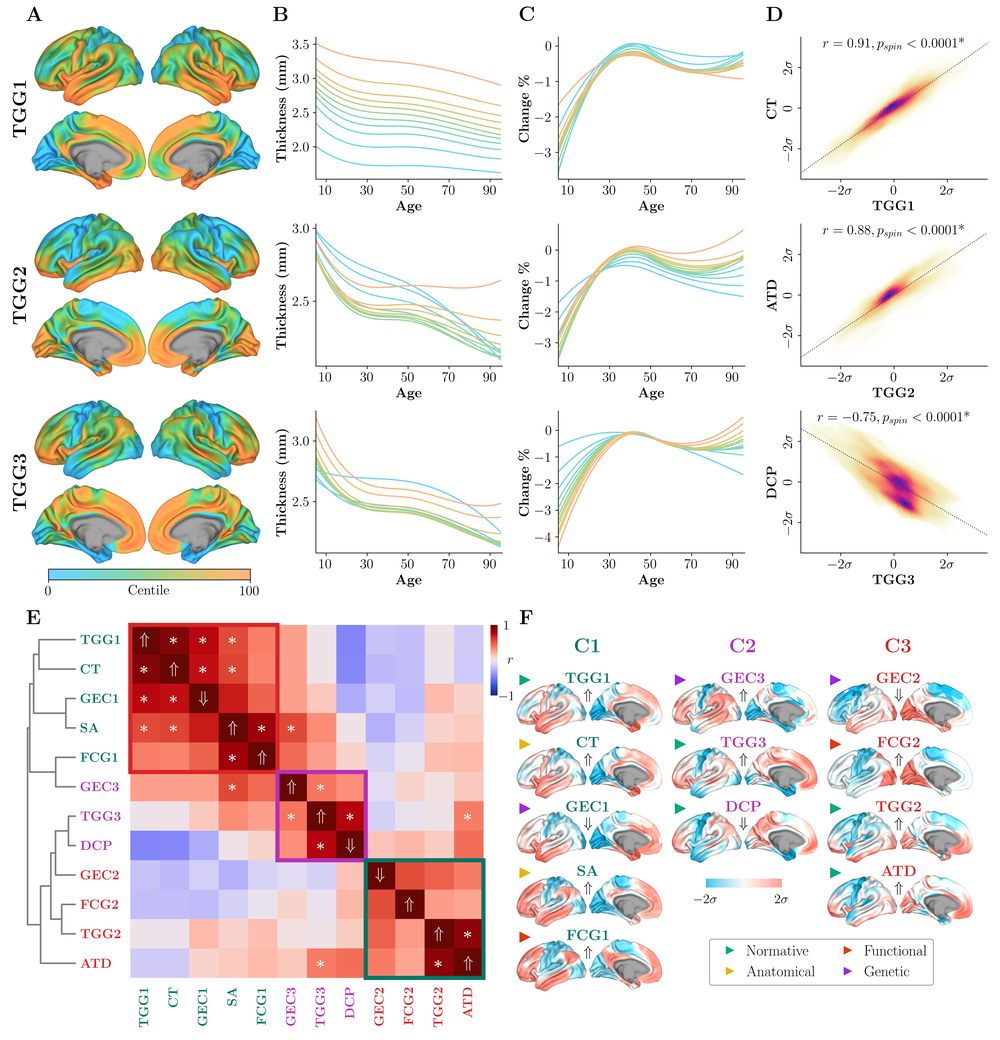

CPU times: user 21 s, sys: 4.44 s, total: 25.5 s
Wall time: 25.3 s


In [48]:
%%time
%matplotlib agg

# save path
store_dir='/mountpoint/code/projects/normative_brain_charts/figs/R1'

fig = plt.figure(figsize=(20, 20.5))
fig.tight_layout(h_pad=0)

outer_gs = gridspec.GridSpec(2, 1, figure=fig, height_ratios=[12,8.5], wspace=0.02, hspace=0.02, top=0.85)

# Brain map cluster analysis
ax = fig.add_subplot(outer_gs[1, 0])
ax.imshow(mpimg.imread(f'{store_dir}/combined/thickness_growth_components_part_2.png'))
ax.axis('off')

# Thickness growth gradients
ax = fig.add_subplot(outer_gs[0, 0])
ax.imshow(mpimg.imread(f'{store_dir}/combined/thickness_growth_components_part_1.png'))
ax.axis('off')
ax.text(0.02, 0.98, r"\textbf{A}", transform=ax.transAxes, fontsize=22, ha='left', va='bottom', rotation=0)
ax.text(0.27, 0.98, r"\textbf{B}", transform=ax.transAxes, fontsize=22, ha='left', va='bottom', rotation=0)
ax.text(0.52, 0.98, r"\textbf{C}", transform=ax.transAxes, fontsize=22, ha='left', va='bottom', rotation=0)
ax.text(0.77, 0.98, r"\textbf{D}", transform=ax.transAxes, fontsize=22, ha='left', va='bottom', rotation=0)
ax.text(0.02, -0.04, r"\textbf{E}", transform=ax.transAxes, fontsize=22, ha='left', va='bottom', rotation=0, clip_on=False, zorder=30)
ax.text(0.52, -0.04, r"\textbf{F}", transform=ax.transAxes, fontsize=22, ha='left', va='bottom', rotation=0, clip_on=False, zorder=30)


image_path = f'{store_dir}/combined/thickness_growth_components_final.png'
fig.savefig(ensure_dir(image_path), bbox_inches="tight", dpi=600)
plt.close('all')
show_image(image_path)


## ATD vs DCP

---

Let's further compare aging related thinning pattern against developmental pruning pattern.



In [49]:
(
    triu_vector_to_symmetric_matrix(network_stats['corellation r'])[map_list.index('DCP'),map_list.index('ATD')],
    triu_vector_to_symmetric_matrix(network_stats['non-parametric p-val'])[map_list.index('DCP'),map_list.index('ATD')],
)

(-0.42693076896140947, 0.01749912504374781)

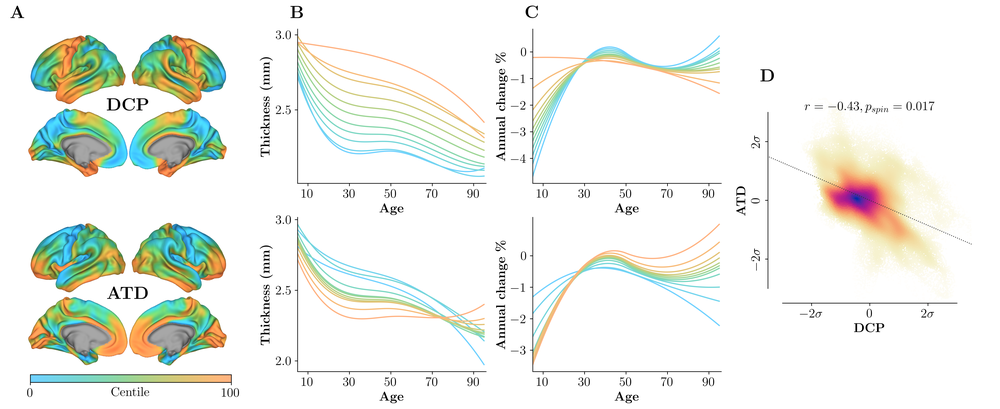

CPU times: user 39.5 s, sys: 1.58 s, total: 41.1 s
Wall time: 35.7 s


In [50]:
%%time
%matplotlib agg

# save path
store_dir='/mountpoint/code/projects/normative_brain_charts/figs/R1'

fig = plt.figure(figsize=(22, 8))
fig.tight_layout(h_pad=0)

outer_gs = gridspec.GridSpec(2, 4, figure=fig, height_ratios=[1, 1], width_ratios=[1.3,1,1,1.2], wspace=0.22, hspace=0.22, top=0.85)

selected_maps = ["DCP", "ATD"]

# TGCs
for i in range(2):
    map_name = selected_maps[i]
    ax = fig.add_subplot(outer_gs[i, 0])
    ax.axis('off')
    iax = ax.inset_axes((0, 0., 1, 1.))
    iax.imshow(mpimg.imread(f'{store_dir}/subfigs/gradients/{map_name}_centiles_projection.png'))
    iax.axis('off')
    iax.text(0.5, 0.5, rf"\textbf{{{map_name}}}", transform=iax.transAxes, fontsize=22, ha='center', va='center', rotation=0)
    if i == 0:
        ax.text(0.05, 1.1, rf"\textbf{{A}}", transform=ax.transAxes, fontsize=22, ha='center', va='center', rotation=0)
    else:
        cax = ax.inset_axes((0.1, -0.07, 0.82, 0.05))    
        cb = fig.colorbar(
            mpl.cm.ScalarMappable(
                norm=mpl.colors.Normalize(vmin=0, vmax=100),
                cmap=cc.cm.isoluminant_cgo_80_c38
            ),
            cax=cax,
            aspect=10,
            orientation='horizontal',
        )
        cax.tick_params(labelsize=16)
        cax.set_xlabel(r'Centile', fontsize=16, labelpad=-15,)
        cax.set_xticks([0, 100])
        cax.set_xticklabels(["0", "100"], rotation=0, fontdict={'ha':'center'})

    # mean thickness
    ax = fig.add_subplot(outer_gs[i, 1])
    ax.set_yticks([2, 2.5, 3, 3.5])
    ax.set_xlim(5, 96)
    ax.set_xticks([10, 30, 50, 70, 90])
    ax.tick_params(labelsize=16)
    if i == 0:
        ax.text(0., 1.1, rf"\textbf{{B}}", transform=ax.transAxes, fontsize=22, ha='center', va='center', rotation=0)
    for j, centile in enumerate(centiles):
        ax.plot(
            candidate_ages,
            brain_maps[map_name]["Centile Group Charts"]['moments']['mu_estimate'][:,j],
            c=cc.cm.isoluminant_cgo_80_c38(centile/100)[:3],
        )
    ax.set_xlabel(r'\textbf{Age}', fontsize=16)
    ax.set_ylabel(r"\textbf{Thickness (mm)}", fontsize=16,)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    # % change
    ax = fig.add_subplot(outer_gs[i, 2])
    ax.set_yticks([0, -1, -2, -3, -4])
    ax.set_xlim(5, 96)
    ax.set_xticks([10, 30, 50, 70, 90])
    ax.tick_params(labelsize=16)
    if i == 0:
        ax.text(0., 1.1, rf"\textbf{{C}}", transform=ax.transAxes, fontsize=22, ha='center', va='center', rotation=0)
    for j, centile in enumerate(centiles):
        ax.plot(
            candidate_ages,
            brain_maps[map_name]["Centile Group Charts"]['rate'][:,j]*100,
            c=cc.cm.isoluminant_cgo_80_c38(centile/100)[:3],
        )
    ax.set_xlabel(r'\textbf{Age}', fontsize=16)
    ax.set_ylabel(r"\textbf{Annual change \%}", fontsize=16,)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

# correspondence
pax = fig.add_subplot(outer_gs[:, 3:])
pax.axis('off')
ax = pax.inset_axes((0, 0.2, 0.9, 0.6))
# Compute point density
x = (brain_maps[selected_maps[0]]["map"]).copy()
y = (brain_maps[selected_maps[1]]["map"]).copy()
xy = np.vstack([x, y])
z = stats.gaussian_kde(xy)(xy)
# axis limits
x_mean, x_std, y_mean, y_std= x.mean(), x.std(), y.mean(), y.std()
ax.set_xlim(x_mean - 3.5 * x_std, x_mean + 3.5 * x_std)
ax.set_ylim(y_mean - 3.5 * y_std, y_mean + 3.5 * y_std)
ax.set_xticks([x_mean - 2 * x_std, x_mean, x_mean + 2 * x_std])
ax.set_xticklabels([r"$-2\sigma$", r"$0$", r"$2\sigma$"])
ax.set_yticks([y_mean - 2 * y_std, y_mean, y_mean + 2 * y_std])
ax.set_yticklabels([r"$-2\sigma$", r"$0$", r"$2\sigma$"], rotation=90, fontdict={'va':'center'})
ax.scatter(x, y, c=z, s=1, cmap=cc.cm.linear_worb_100_25_c53)
ax.set_xlabel(rf'\textbf{{{selected_maps[0]}}}', fontsize=16)
ax.set_ylabel(rf'\textbf{{{selected_maps[1]}}}', fontsize=16)
# Regression line
m, b = np.polyfit(x, y, 1)
x_line = np.linspace(x_mean - 4 * x_std, x_mean + 4 * x_std, 2)
ax.plot(x_line, m * x_line + b, color='#333', linewidth=1, linestyle=':')
ax.tick_params(labelsize=16)
r = np.corrcoef(x,y)[0,1]
ax.text(0.5, 0.95, rf"$r={{{r:.2f}}},p_{{spin}}=0.017$", transform=ax.transAxes, fontsize=16, ha='center', va='center', rotation=0)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_bounds(y_mean - 3 * y_std, y_mean + 3 * y_std)
ax.spines['bottom'].set_bounds(x_mean - 3 * x_std, x_mean + 3 * x_std)
ax.text(0., 1.1, rf"\textbf{{D}}", transform=ax.transAxes, fontsize=22, ha='center', va='center', rotation=0)

image_path = f'{store_dir}/combined/atd_dcp_comparison.png'
fig.savefig(ensure_dir(image_path), bbox_inches="tight", dpi=600)
plt.close('all')
show_image(image_path)


## Store the derived maps

---

Let's store the derived maps (TGG1-3, DCP, & ATD) for future use.



In [51]:
template_img = nib.load(cbu.cifti_template_file)

for map_name in tqdm(["TGG1", "TGG2", "TGG3", "ATD", "DCP"]):
    # save as npy
    np.save(
        f'/mountpoint/code/projects/normative_brain_charts/data/brainmaps/{brain_maps[map_name]["name"].replace(" ", "_")}.npy',
        brain_maps[map_name]["map"]
    )

    # save as dscalar
    new_shape = brain_maps[map_name]["map"].shape[0]
    cifti2_img = nib.Cifti2Image(
        dataobj=brain_maps[map_name]["map"].copy().reshape(1, -1),
        header=nib.cifti2.Cifti2Header.from_axes(
            (
                nib.cifti2.ScalarAxis([f'{brain_maps[map_name]["name"]}']),
                nib.cifti2.cifti2_axes.BrainModelAxis(
                    name=template_img.header.get_axis(1).name[:new_shape],
                    voxel=template_img.header.get_axis(1).voxel[:new_shape],
                    vertex=template_img.header.get_axis(1).vertex[:new_shape],
                    affine=template_img.header.get_axis(1).affine,
                    volume_shape=template_img.header.get_axis(1).volume_shape,
                    nvertices=template_img.header.get_axis(1).nvertices,
                ),
            ),
        ),
    )
    out_file=ensure_dir(f'/mountpoint/code/projects/normative_brain_charts/data/brainmaps/{brain_maps[map_name]["name"].replace(" ", "_")}.dscalar.nii')
    nib.save(cifti2_img, out_file)


  0%|          | 0/5 [00:00<?, ?it/s]